## Importer les librairies necessaires

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Missing data imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Categorical data encoding
from sklearn.preprocessing import LabelEncoder

# Train-test split and k-fold cross validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Resampling
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Classification algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn import metrics
from sklearn.metrics import f1_score

# Warning suppression
import warnings
warnings.filterwarnings('ignore')

## Chargement et Exploration des donnees

In [2]:
df = pd.read_csv("data/raw/accidents_2019_2023.csv", sep=';', low_memory=False)

In [3]:
# Printing the top 5 rows
df.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,30,11,2019,01:30,4,93,93053,1,1,...,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,30,11,2019,01:30,4,93,93053,1,1,...,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,30,11,2019,01:30,4,93,93053,1,1,...,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,30,11,2019,02:50,3,93,93066,1,1,...,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,28,11,2019,15:15,1,92,92036,1,1,...,1,1996.0,0,1,0,-1,-1,0,-1,NaN


In [4]:
# Shape of the data
print("Shape of the df: {}".format(df.shape))

Shape of the df: (528617, 55)


In [5]:
# Column names
df.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long', 'catr', 'voie', 'v1', 'v2',
       'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout',
       'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'num_veh', 'senc',
       'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc', 'place',
       'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3',
       'locp', 'actp', 'etatp', 'id_usager'],
      dtype='object')

In [6]:
print("Total number of columns: {}".format(len(df.columns)))

Total number of columns: 55


In [7]:
df.dtypes

Num_Acc          int64
jour             int64
mois             int64
an               int64
hrmn            object
lum              int64
dep             object
com             object
agg              int64
int              int64
atm              int64
col              int64
adr             object
lat             object
long            object
catr             int64
voie            object
v1             float64
v2              object
circ             int64
nbv             object
vosp             int64
prof             int64
pr              object
pr1             object
plan             int64
lartpc          object
larrout         object
surf             int64
infra            int64
situ             int64
vma              int64
id_vehicule     object
num_veh         object
senc             int64
catv             int64
obs              int64
obsm             int64
choc             int64
manv             int64
motor            int64
occutc         float64
place            int64
catu       

In [8]:
# Count of duplicate rows
duplicate = df[df.duplicated() == True]
print("Number of duplicate rows: {}".format(len(duplicate)))

Number of duplicate rows: 164


In [9]:
# Count of missing values in each column
df.isna().sum()

Num_Acc             0
jour                0
mois                0
an                  0
hrmn                0
lum                 0
dep                 0
com                 0
agg                 0
int                 0
atm                 0
col                 0
adr              8737
lat                 0
long                0
catr                0
voie            66748
v1              24596
v2             486730
circ                0
nbv                 0
vosp                0
prof                0
pr                  0
pr1                 0
plan                0
lartpc         527703
larrout        132146
surf                0
infra               0
situ                0
vma                 0
id_vehicule         0
num_veh             0
senc                0
catv                0
obs                 0
obsm                0
choc                0
manv                0
motor               0
occutc         521059
place               0
catu                0
grav                0
sexe      

In [10]:
print("Total number of missing values: {}".format(df.isna().sum().sum()))
print("Number of columns with missing values: {}".format(len(df.isnull().sum().tolist())-df.isnull().sum().tolist().count(0)))
print("Number of columns without missing values: {}".format(df.isnull().sum().tolist().count(0)))

Total number of missing values: 2012377
Number of columns with missing values: 9
Number of columns without missing values: 46


In [11]:
# Summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528617 entries, 0 to 528616
Data columns (total 55 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      528617 non-null  int64  
 1   jour         528617 non-null  int64  
 2   mois         528617 non-null  int64  
 3   an           528617 non-null  int64  
 4   hrmn         528617 non-null  object 
 5   lum          528617 non-null  int64  
 6   dep          528617 non-null  object 
 7   com          528617 non-null  object 
 8   agg          528617 non-null  int64  
 9   int          528617 non-null  int64  
 10  atm          528617 non-null  int64  
 11  col          528617 non-null  int64  
 12  adr          519880 non-null  object 
 13  lat          528617 non-null  object 
 14  long         528617 non-null  object 
 15  catr         528617 non-null  int64  
 16  voie         461869 non-null  object 
 17  v1           504021 non-null  float64
 18  v2           41887 non-n

In [12]:
# Statistical description of numerical features
df.describe()

,Num_Acc,jour,mois,an,lum,agg,int,atm,col,catr,...,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,etatp
count,5.286170e+05,528617.000000,528617.000000,528617.000000,528617.000000,528617.000000,528617.000000,528617.000000,528617.000000,528617.000000,...,528617.000000,528617.000000,528617.000000,522231.000000,528617.000000,528617.000000,528617.00000,528617.000000,528617.000000,528617.000000
mean,2.021157e+11,15.562496,6.692420,2021.156595,1.936568,1.629664,2.123430,1.610516,3.739674,3.288831,...,1.335466,2.525640,1.290899,1982.451708,3.203588,1.986105,1.10098,-0.906914,-0.192968,-0.821321
std,1.630668e+08,8.734388,3.377807,1.630670,1.500676,0.482895,1.974946,1.673232,1.883392,1.226066,...,0.615480,1.378214,0.524040,19.075507,2.750135,2.372102,3.10846,0.920526,1.238159,0.629845
min,2.019000e+11,1.000000,1.000000,2019.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,-1.000000,-1.000000,1900.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000
25%,2.019001e+11,8.000000,4.000000,2019.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1969.000000,0.000000,1.000000,-1.00000,-1.000000,-1.000000,-1.000000
50%,2.022000e+11,15.000000,7.000000,2022.000000,1.000000,2.000000,1.000000,1.000000,3.000000,3.000000,...,1.000000,3.000000,1.000000,1986.000000,4.000000,1.000000,0.00000,-1.000000,0.000000,-1.000000
75%,2.023000e+11,23.000000,10.000000,2023.000000,3.000000,2.000000,3.000000,1.000000,6.000000,4.000000,...,2.000000,4.000000,2.000000,1998.000000,5.000000,2.000000,0.00000,-1.000000,0.000000,-1.000000
max,2.023001e+11,31.000000,12.000000,2023.000000,5.000000,2.000000,9.000000,9.000000,7.000000,9.000000,...,3.000000,4.000000,2.000000,2023.000000,9.000000,9.000000,9.00000,9.000000,9.000000,3.000000


## Data Visiualization

In [13]:
# Unique values of grav
df['grav'].unique()

array([ 4,  1,  3,  2, -1], dtype=int64)

In [14]:
# Value counts of grav
df['grav'].value_counts()

grav
 1    223073
 4    210688
 3     80750
 2     13709
-1       397
Name: count, dtype: int64

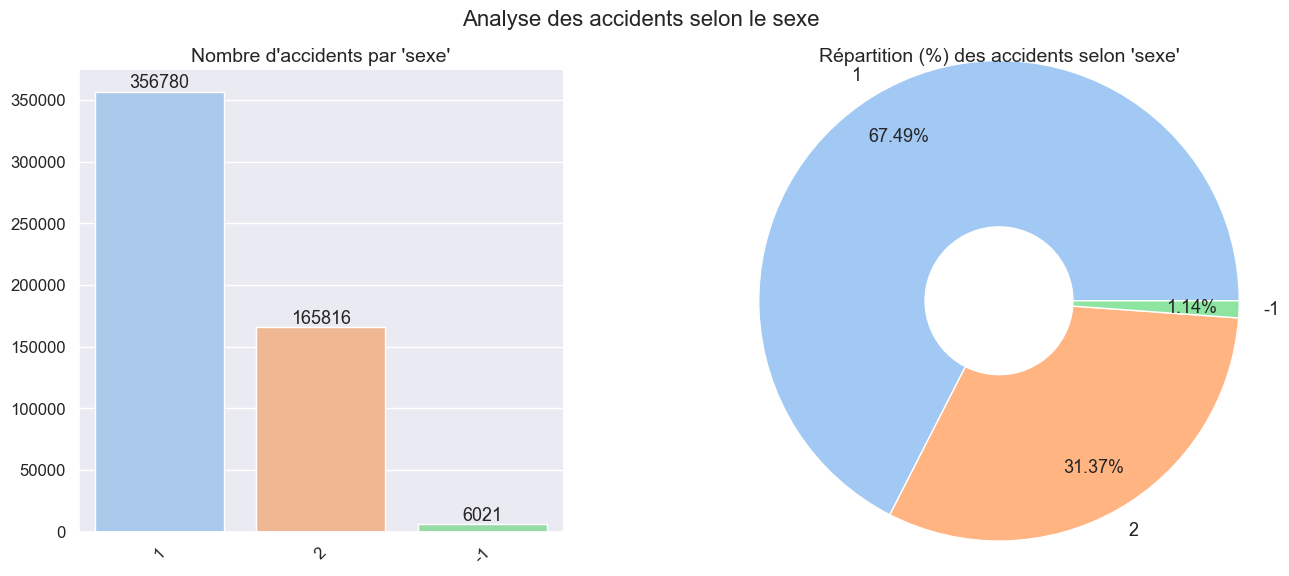

In [15]:
def add_annotations(ax):
    for p in ax.patches:
        frequency = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + p.get_height()
        ax.annotate(f'{frequency}', (x, y), size=13, ha='center', va='bottom')
# Visualization
def count_donut(data, col, title=None):
    data = data.dropna(subset=[col])  # Supprime les valeurs manquantes
 
    plt.figure(figsize=(15, 6))

    # Graphique 1 : Countplot
    ax1 = plt.subplot(1, 2, 1)
    values = data[col].value_counts()
    labels = values.index
    colors = sns.color_palette('pastel')[0:len(values)]

    sns.countplot(x=col, data=data, palette=colors, ax=ax1,
                  order=labels)  # garantit le même ordre
    add_annotations(ax1)
    ax1.set_title(f"Nombre d'accidents par '{col}'", fontsize=14)
    ax1.set_xlabel('')
    ax1.set_ylabel('')
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    sns.despine(top=True, right=True)

    # Graphique 2 : Donut chart
    ax2 = plt.subplot(1, 2, 2)
    plt.pie(values,
            labels=labels,
            autopct='%1.2f%%',
            pctdistance=0.8,
            colors=colors,
            textprops={'fontsize': 13},
            radius=1.3)
    circle = plt.Circle((0, 0), 0.4, fc='white')
    plt.gca().add_artist(circle)
    ax2.set_title(f"Répartition (%) des accidents selon '{col}'", fontsize=14)

    if title:
        plt.suptitle(title, fontsize=16)

    plt.subplots_adjust(wspace=0.4)
    plt.show()

# Exemple d'utilisation avec la variable 'sexe'
count_donut(df, 'sexe', title="Analyse des accidents selon le sexe")


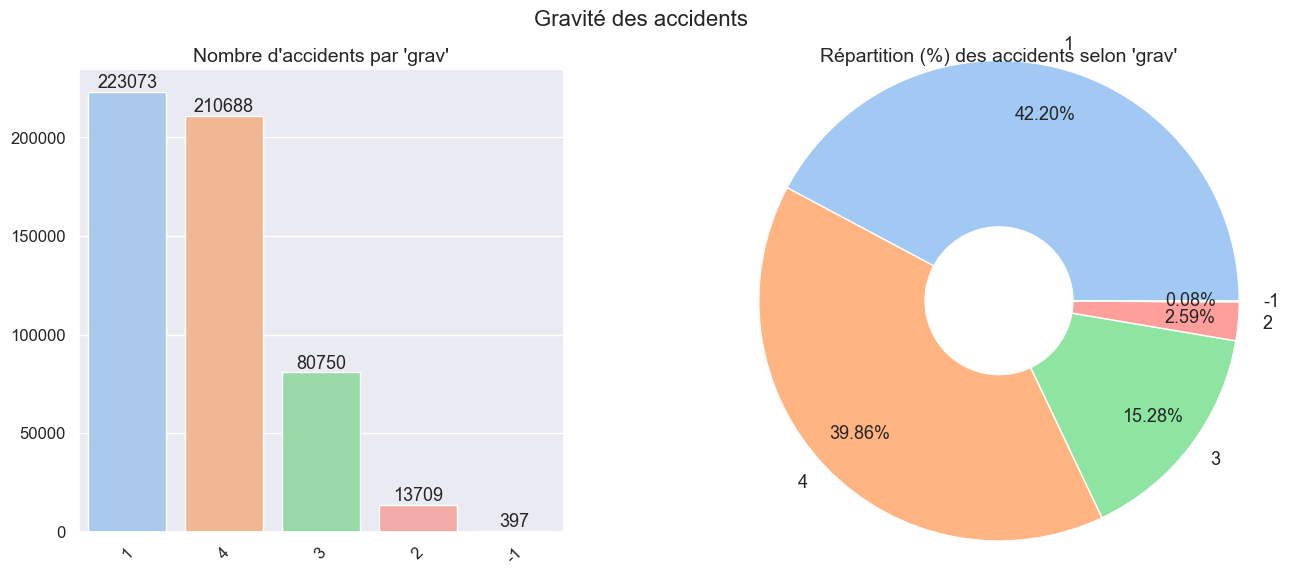

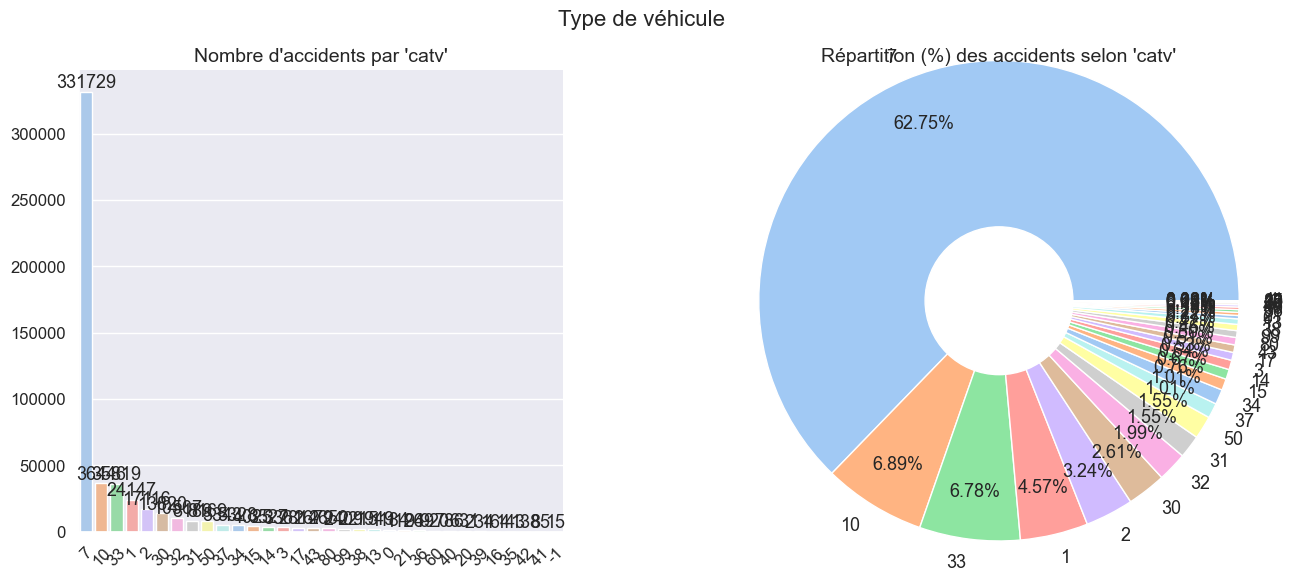

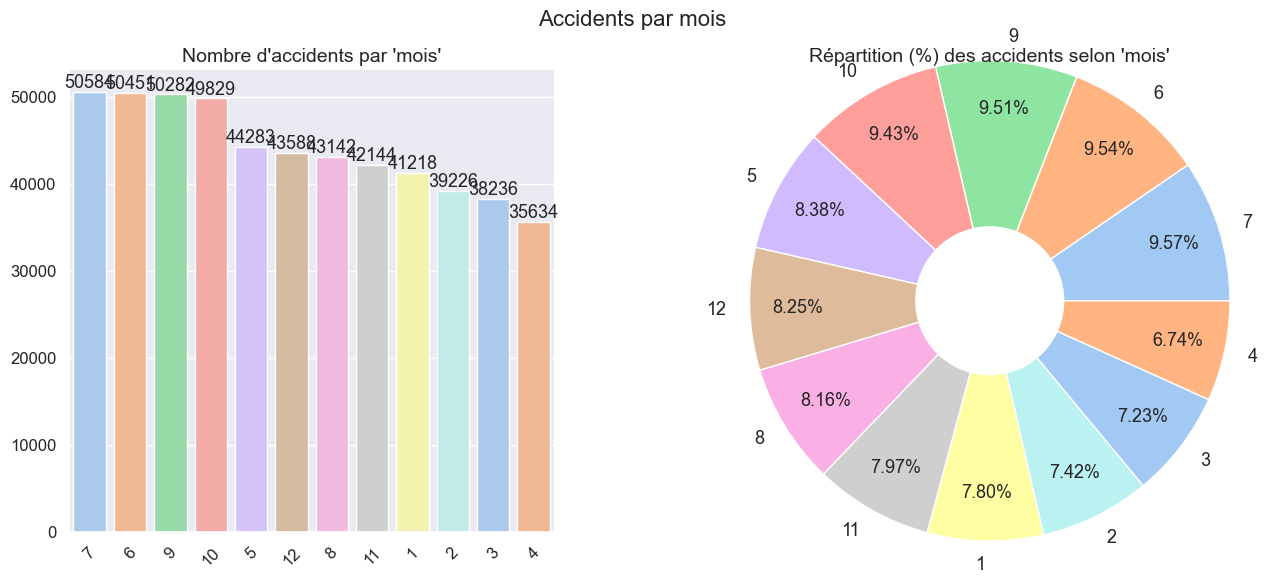

In [16]:
count_donut(df, 'grav', title="Gravité des accidents")
count_donut(df, 'catv', title="Type de véhicule")
count_donut(df, 'mois', title="Accidents par mois")

In [17]:
# Convertion of time from hh:mm:ss format to seconds
def convert_to_seconds(x):
    try:
        h, m, s = map(int, x.split(':'))
        return h * 3600 + m * 60 + s
    except:
        return None  # ou np.nan si tu préfères

df['heure'] = df['hrmn'].apply(convert_to_seconds)

In [18]:
# Création d'une colonne 'date' à partir de jour/mois/an
df['date'] = pd.to_datetime(dict(year=df['an'], month=df['mois'], day=df['jour']), errors='coerce')

# Création du jour de la semaine
df['jour_semaine'] = df['date'].dt.dayofweek  

# Extraction de l'heure depuis la colonne 'hrmn' s
def extraire_heure(chaine):
    try:
        return int(str(chaine).split(':')[0])
    except:
        return np.nan

df['heure'] = df['hrmn'].apply(extraire_heure)

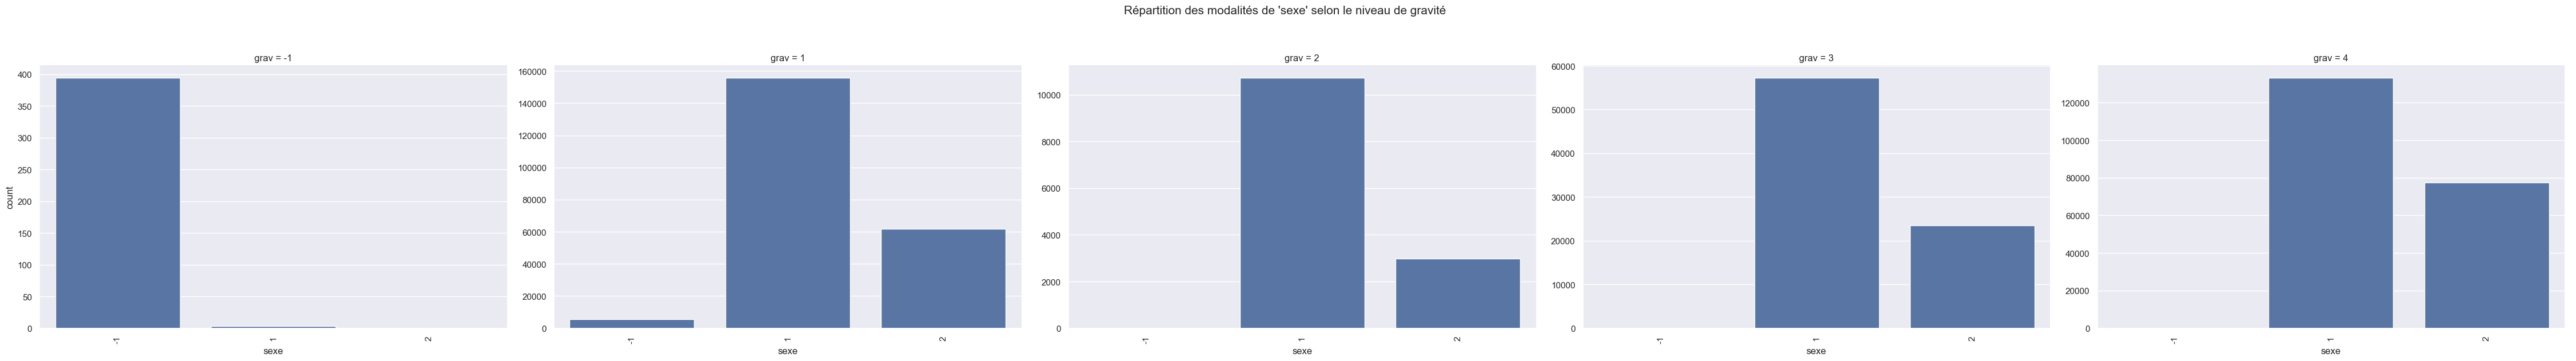

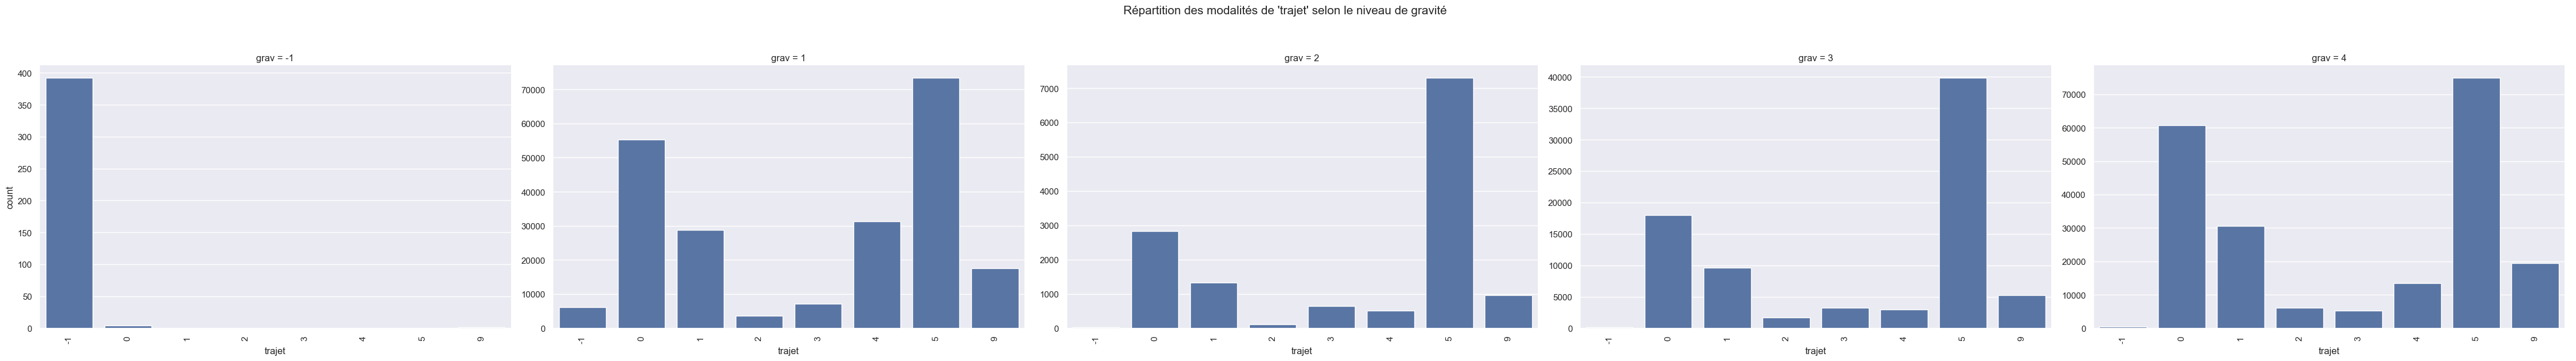

[!] Trop de modalités dans la variable 'catv' pour un catplot lisible.


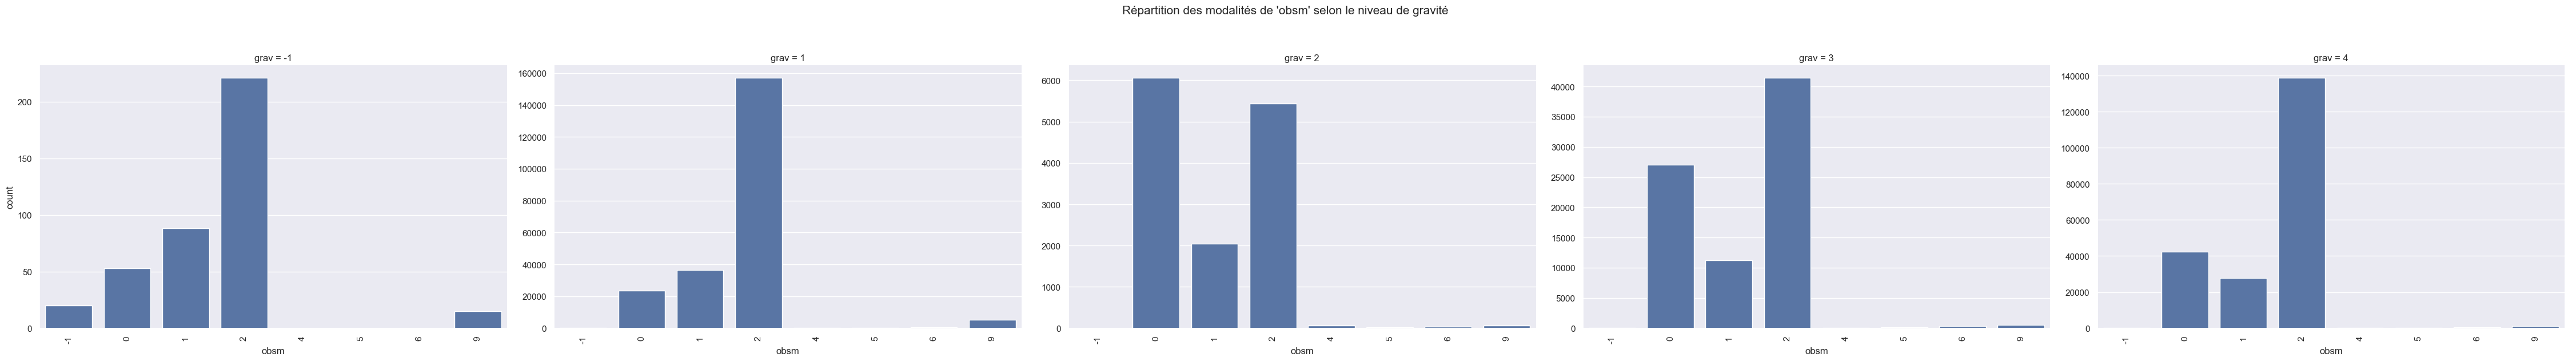

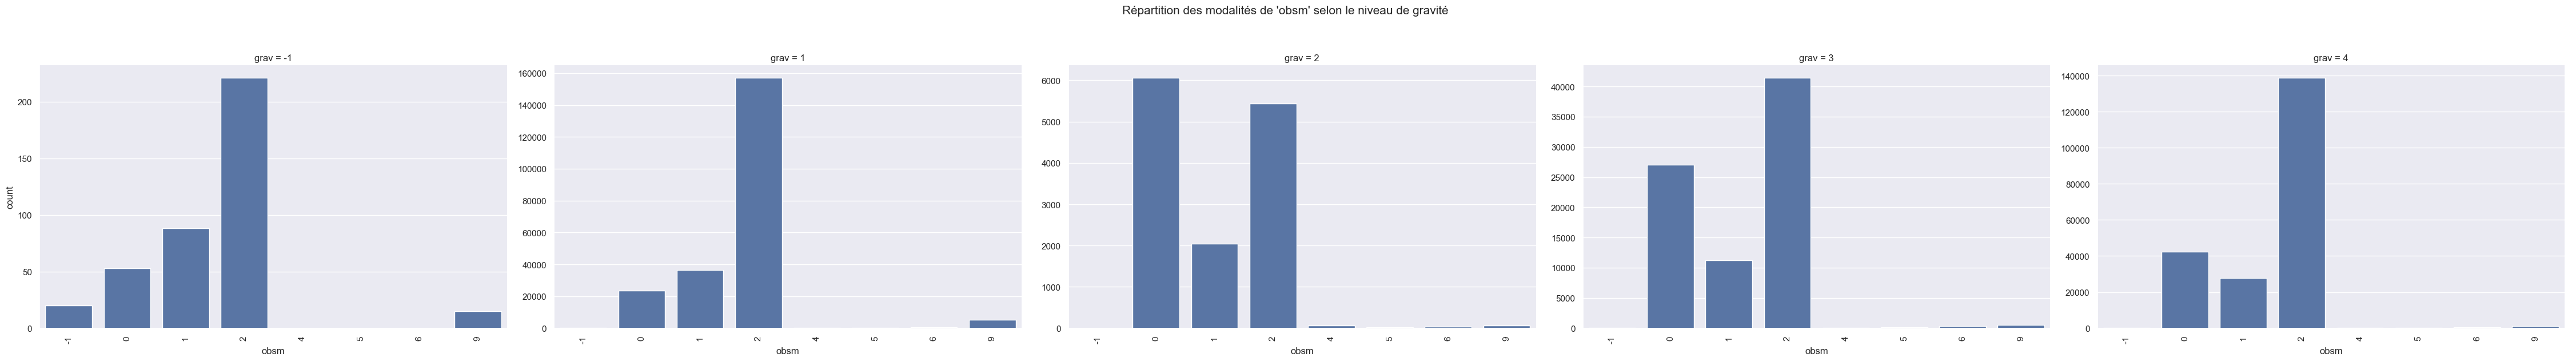

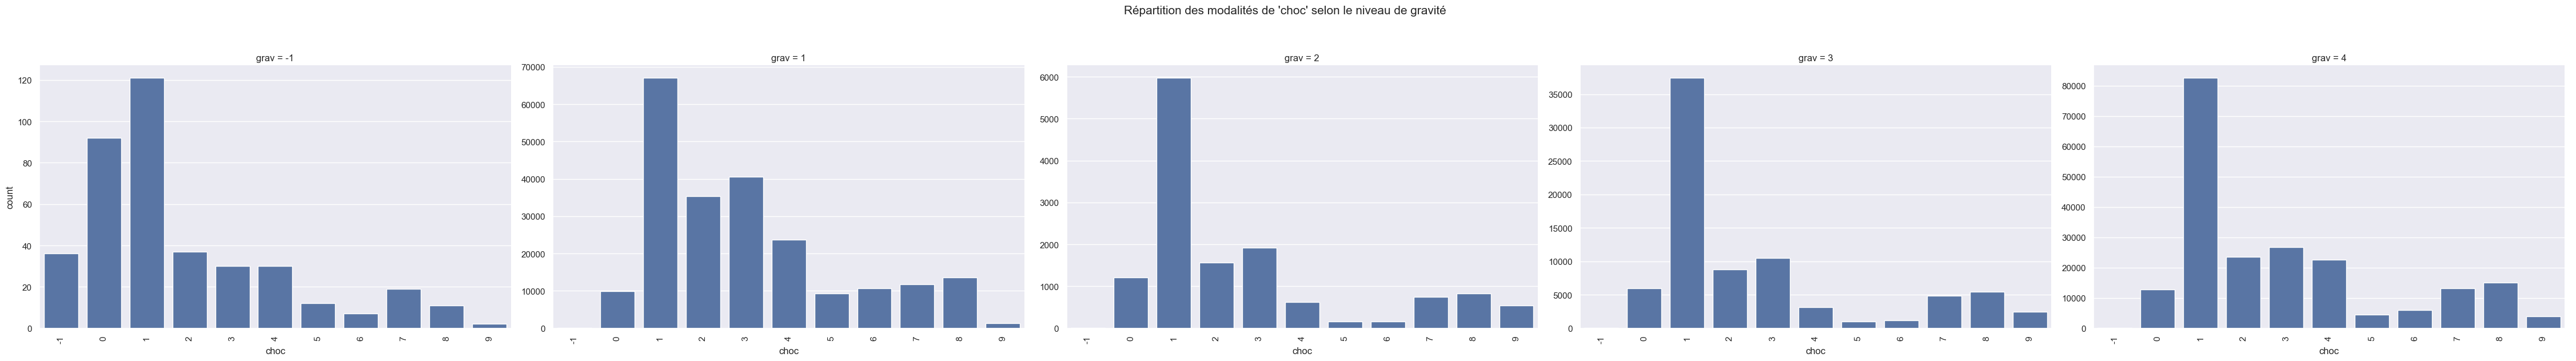

[!] Trop de modalités dans la variable 'manv' pour un catplot lisible.


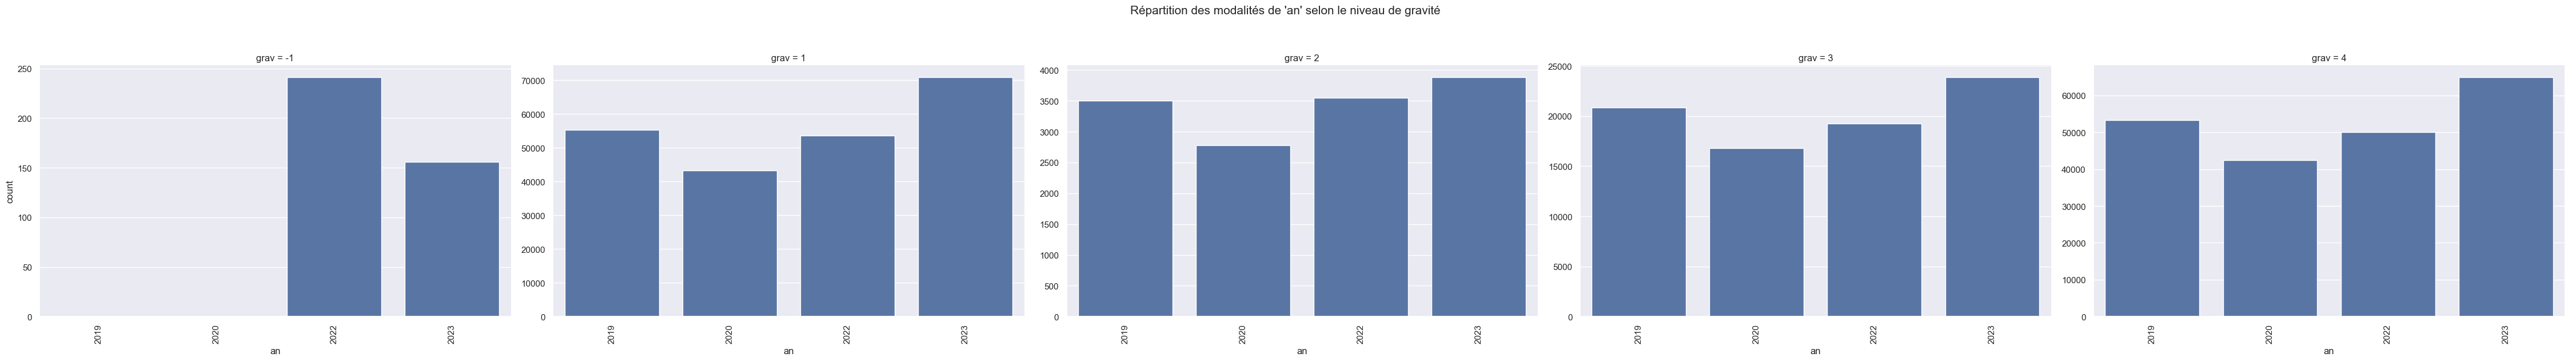

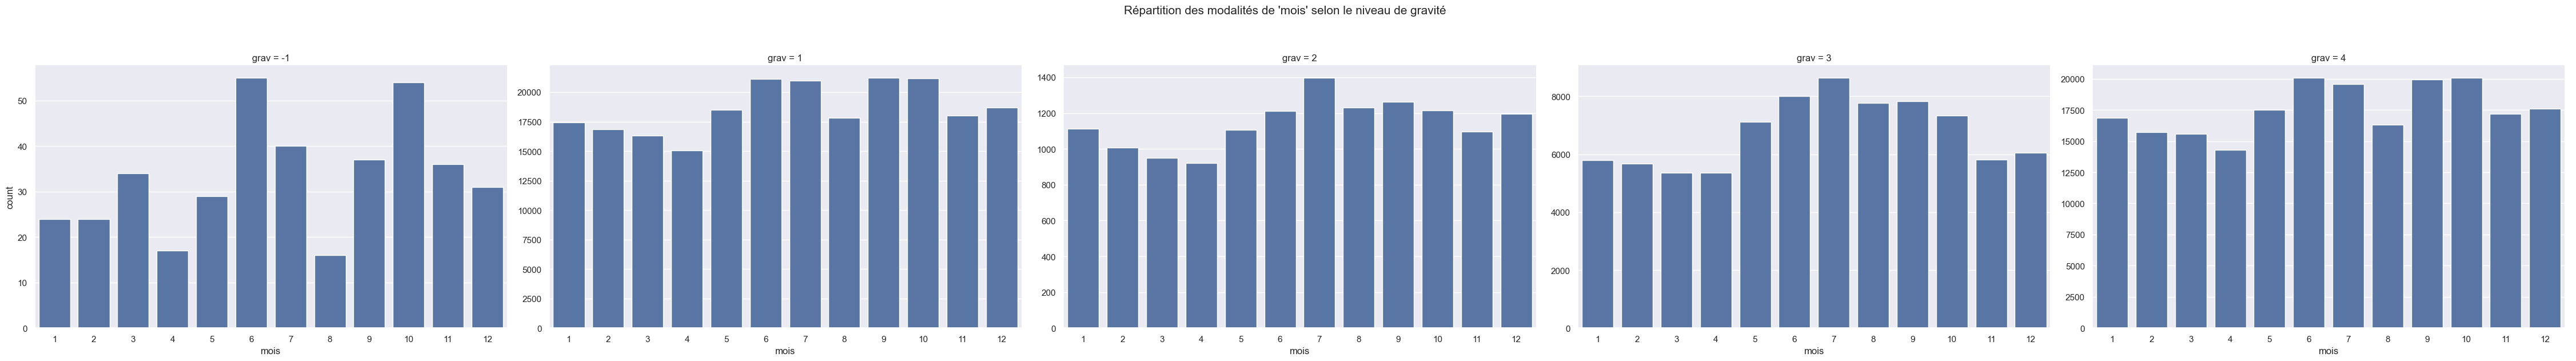

[!] Trop de modalités dans la variable 'jour' pour un catplot lisible.
[!] Trop de modalités dans la variable 'dep' pour un catplot lisible.


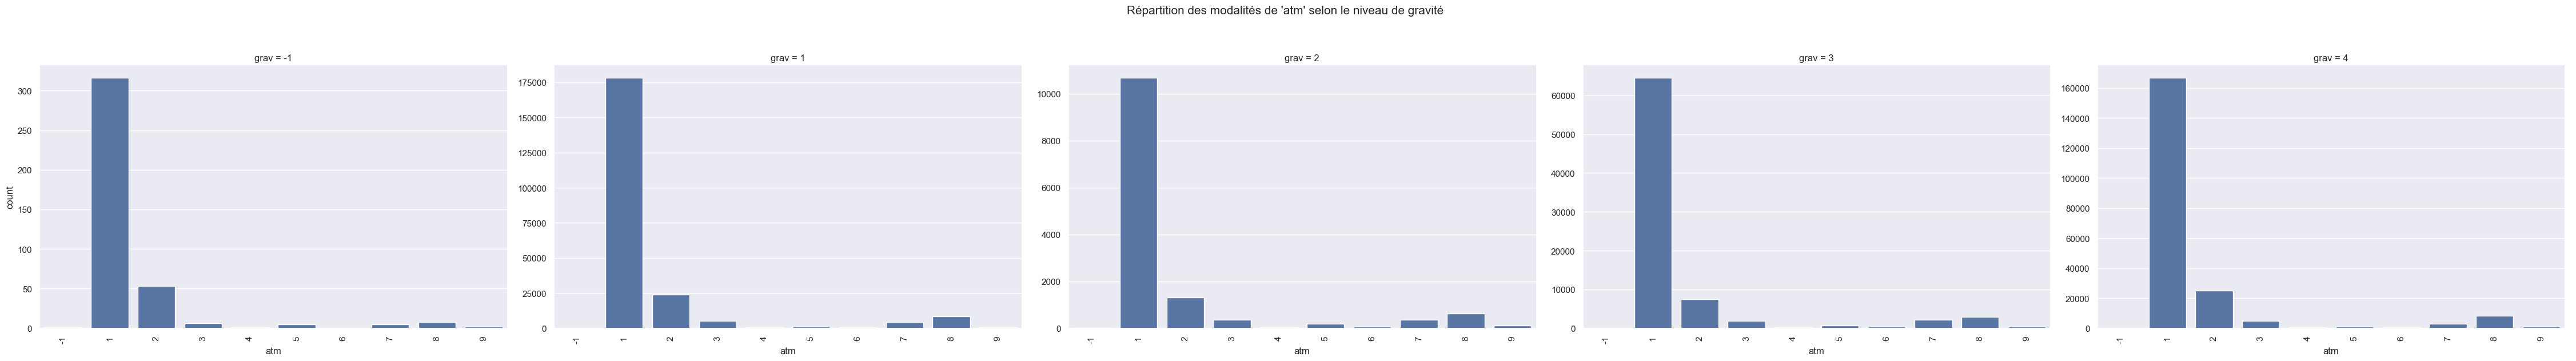

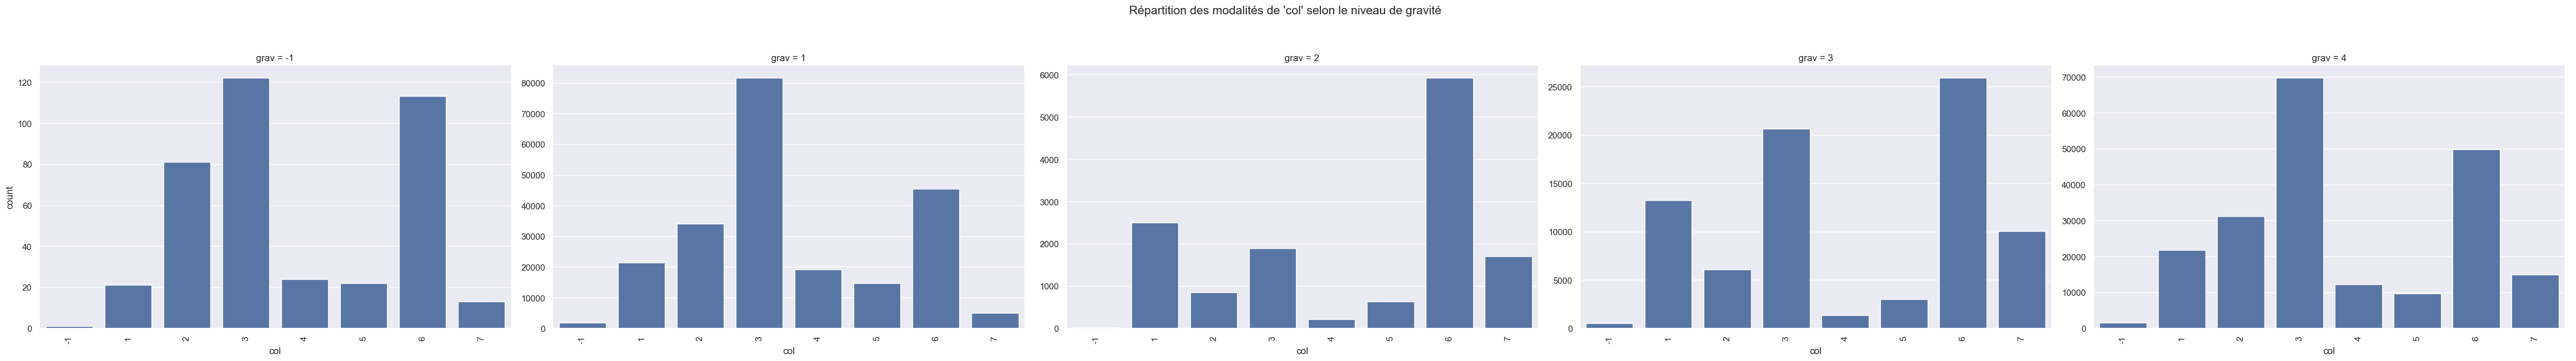

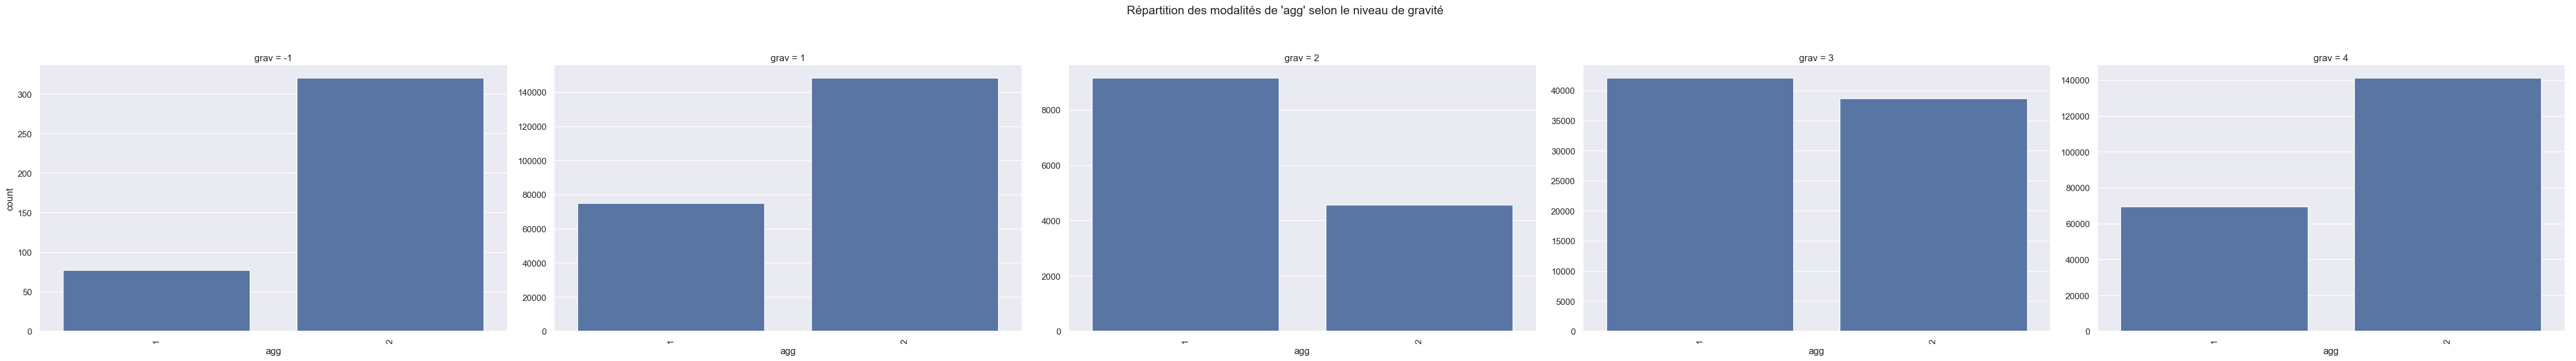

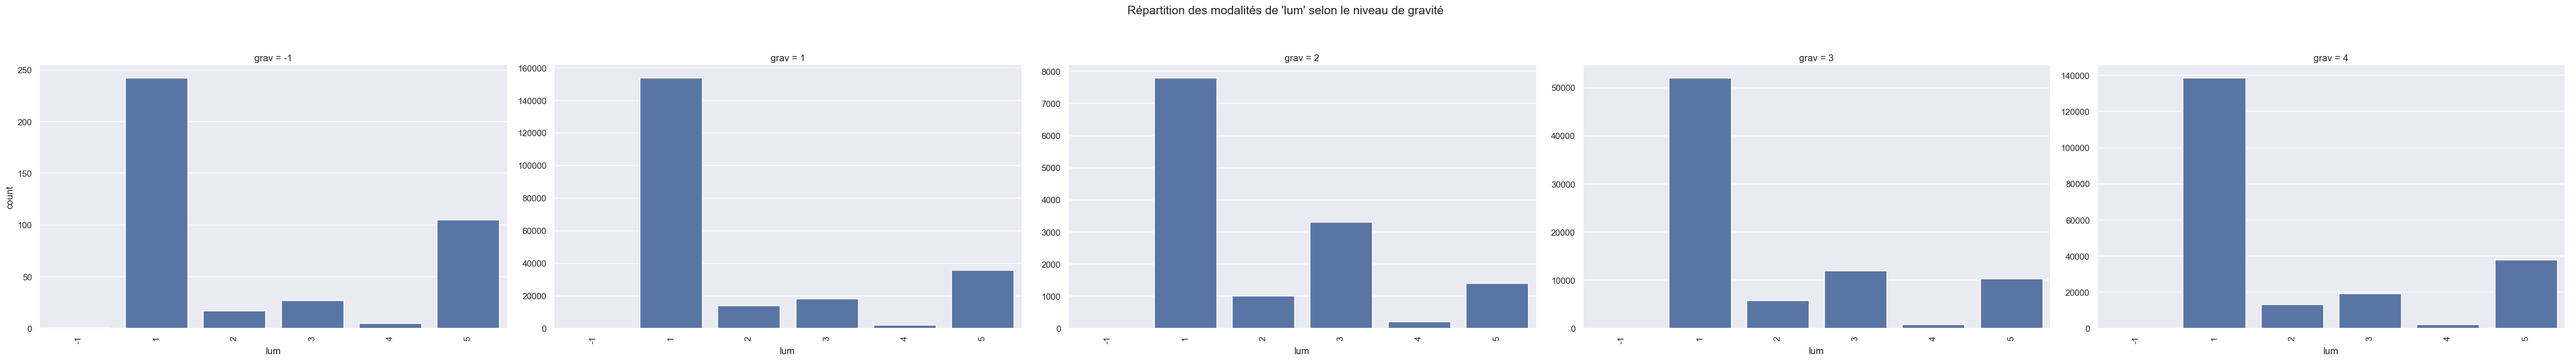

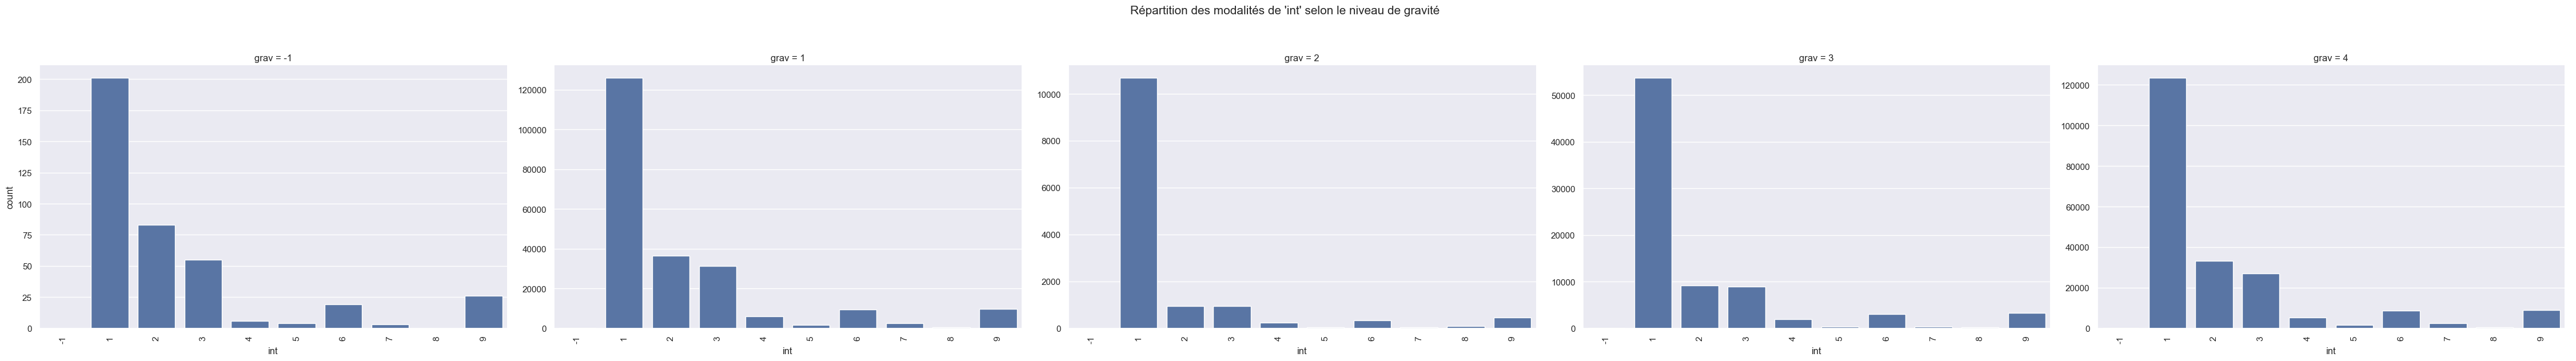

[!] Trop de modalités dans la variable 'com' pour un catplot lisible.


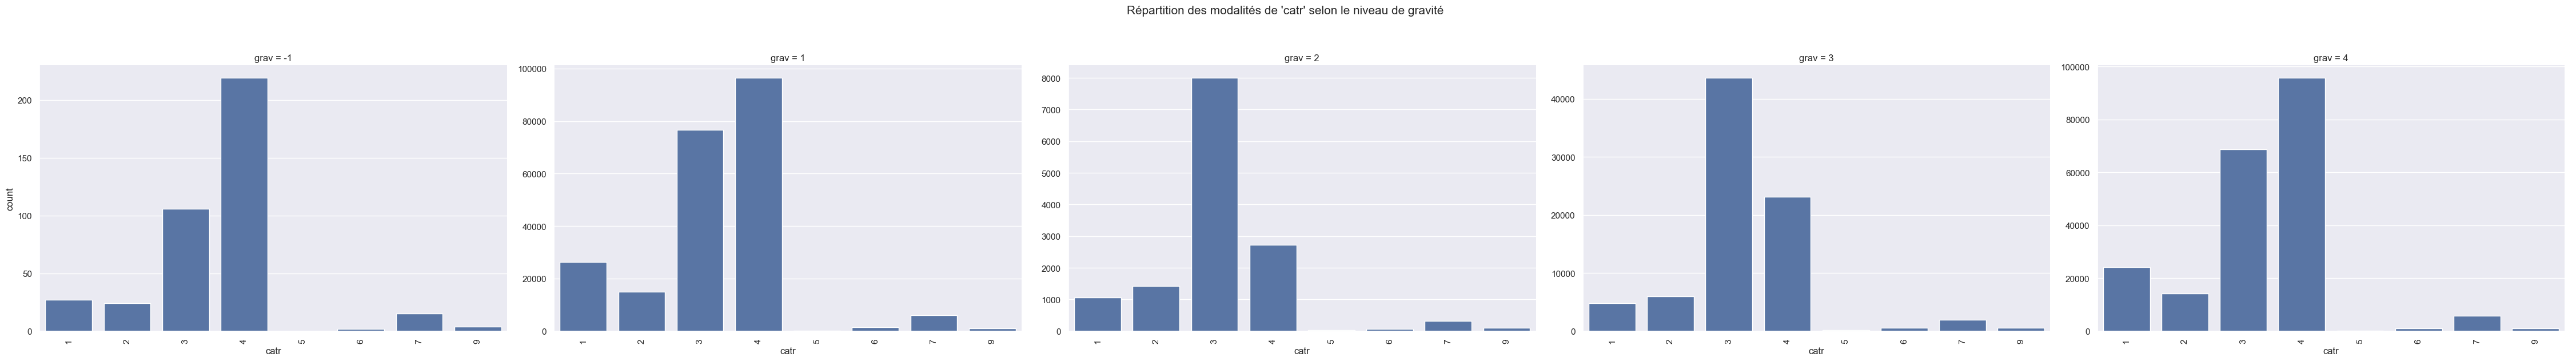

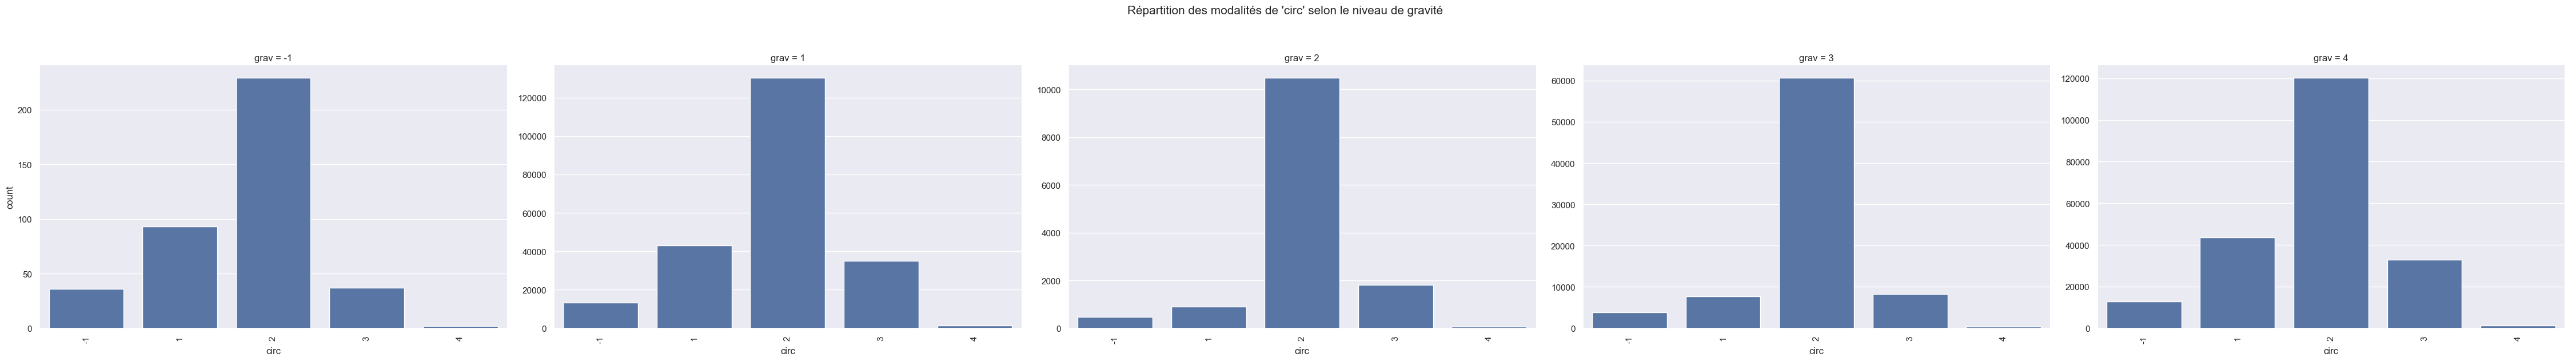

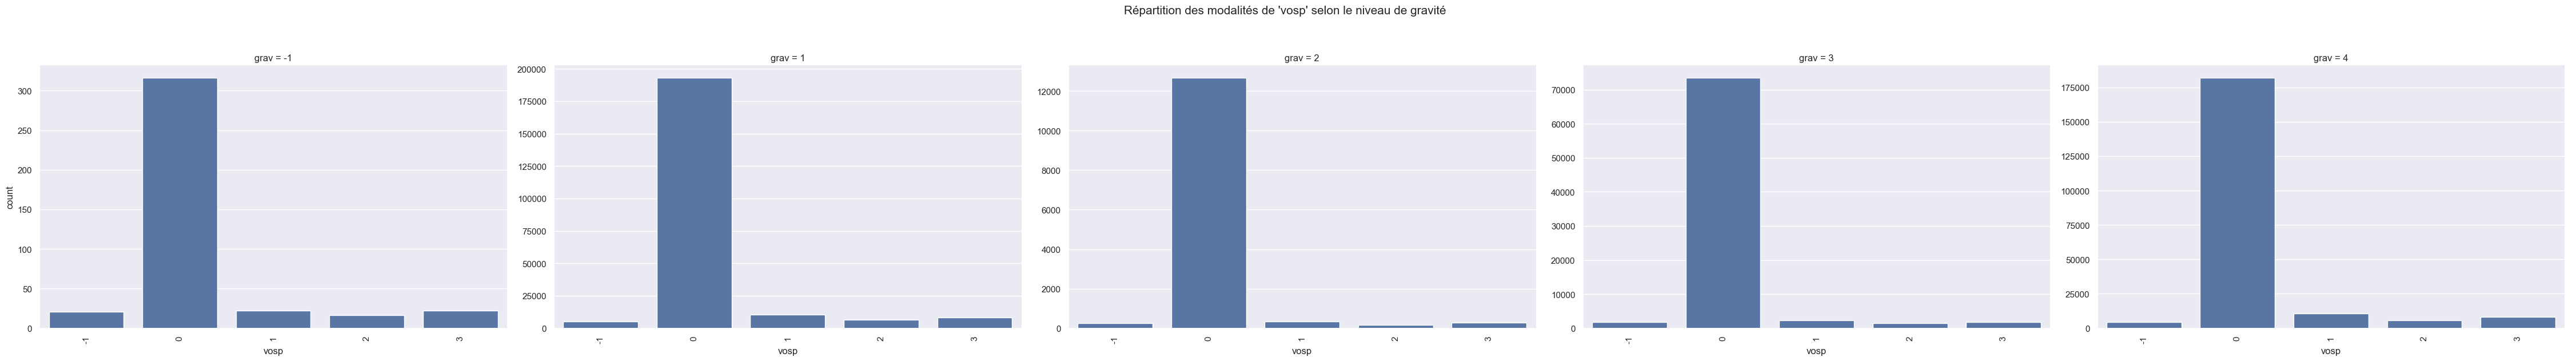

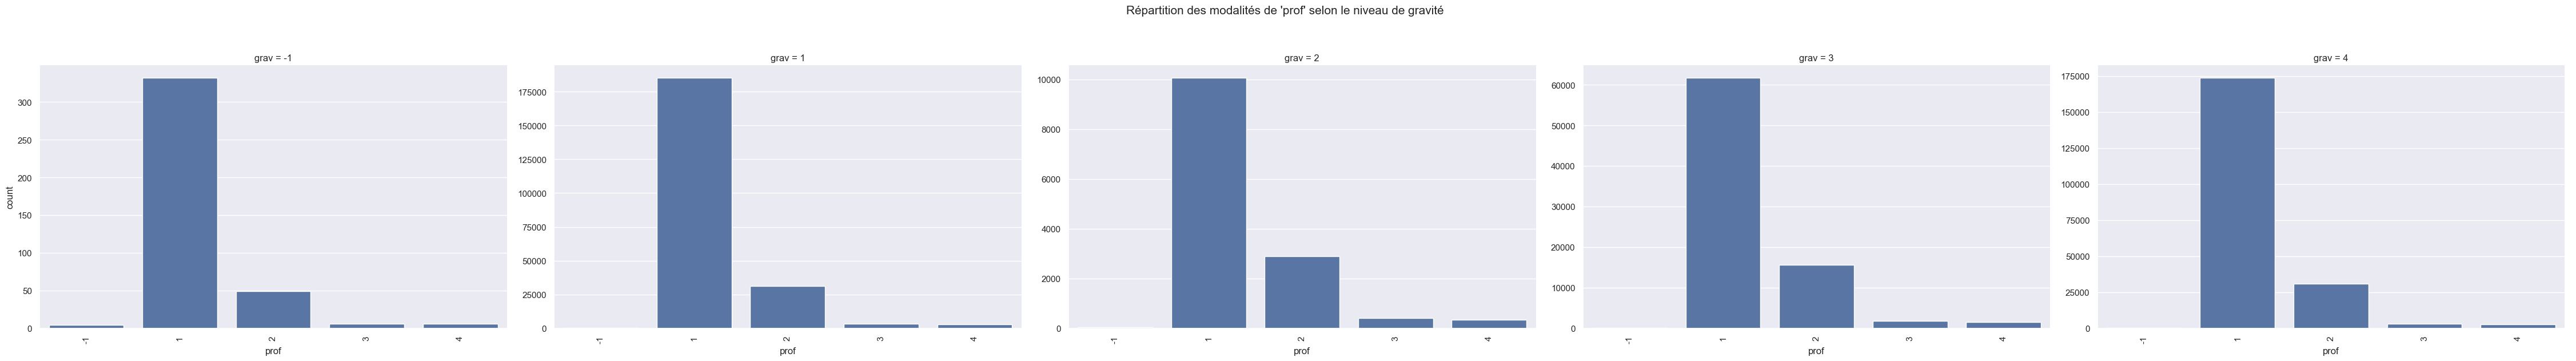

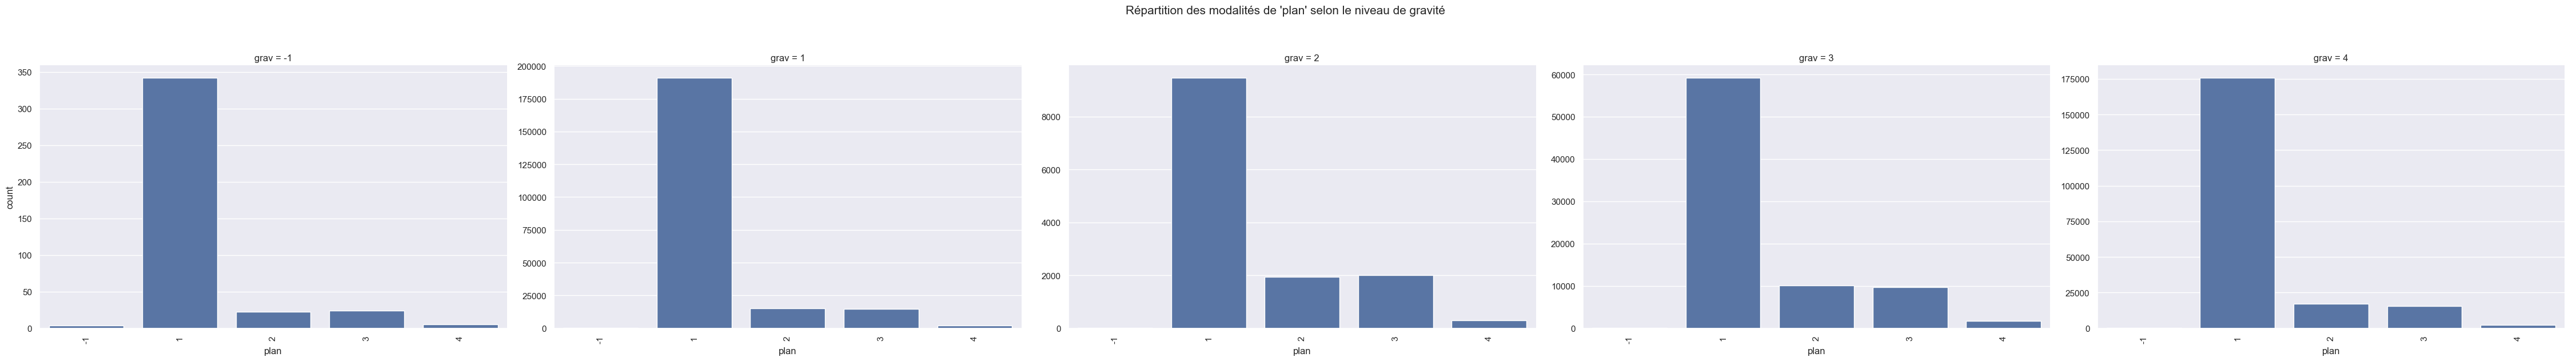

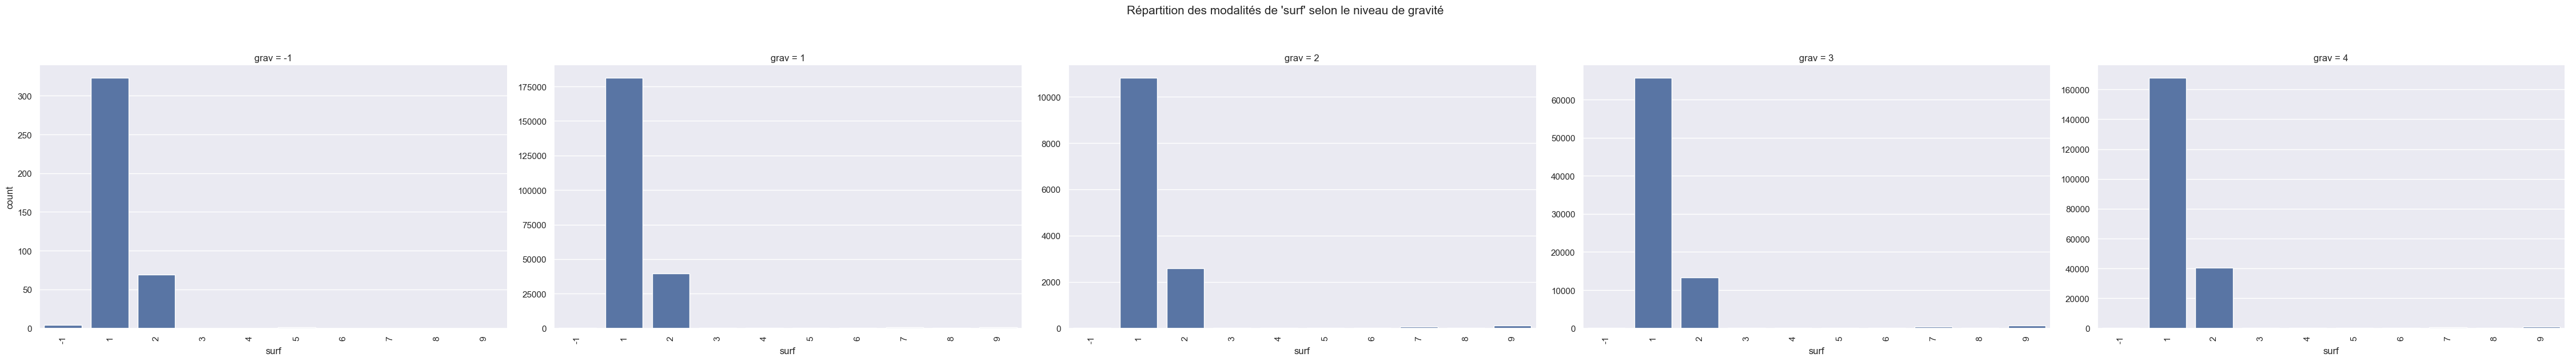

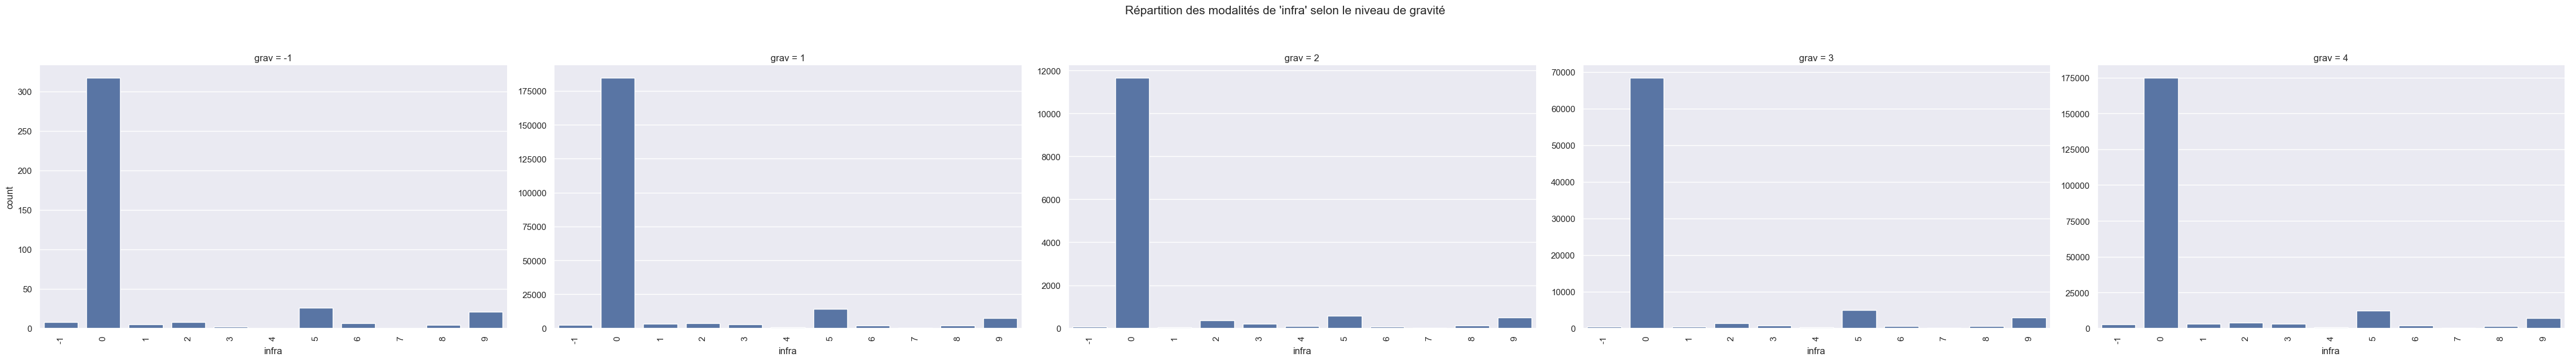

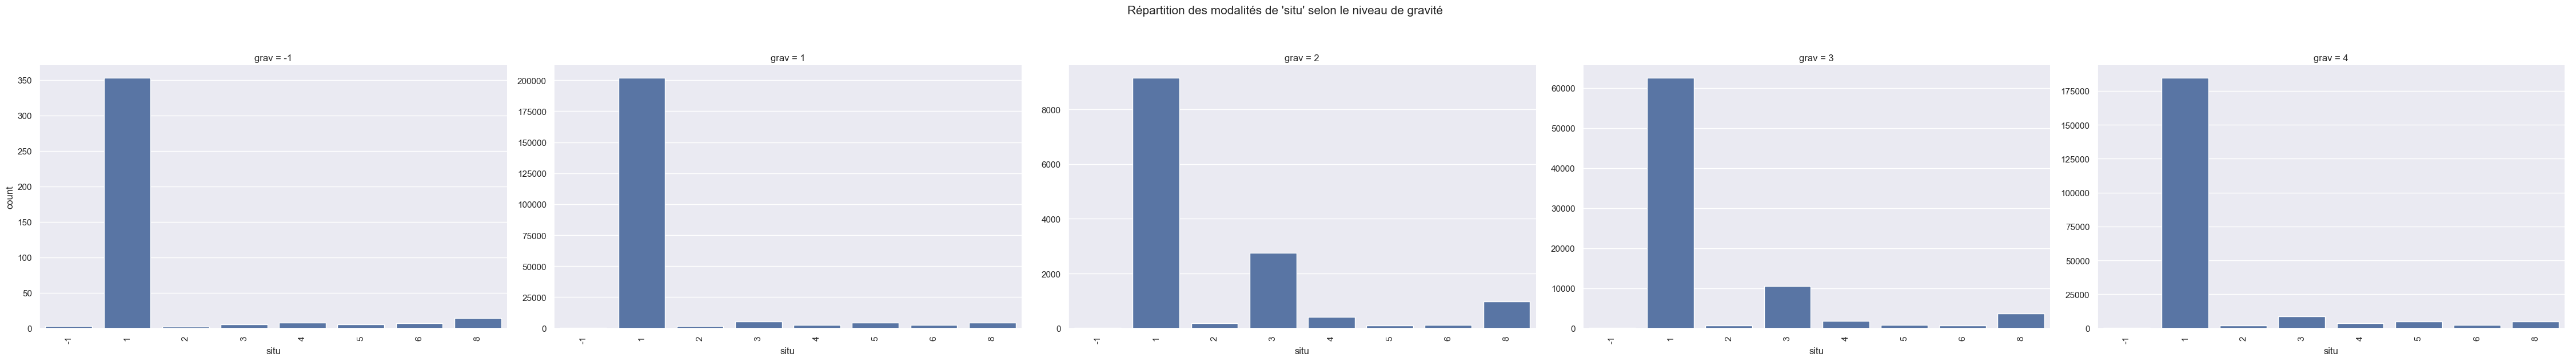

In [19]:
# Catplot pour comparer la répartition des modalités des variables (hors 'heure') selon la gravité
# Liste des variables catégorielles à explorer (hors heure)
features_others = [
    'sexe', 'trajet', 'catv', 'obsm', 'obsm', 'choc', 'manv',
    'an', 'mois', 'jour', 'dep', 'atm', 'col', 'agg', 'lum',
    'int', 'com', 'catr', 'circ', 'vosp', 'prof', 'plan', 'surf',
    'infra', 'situ'
]

# Variables pour lesquelles il faut tourner les étiquettes horizontalement
features_horiz = ['dep', 'com', 'mois', 'jour']
for feature in features_others:
    if feature in df.columns:
        # Nettoyage optionnel
        data = df.dropna(subset=[feature, 'grav'])

        # Vérifie qu'il y a peu de modalités (sinon, le plot devient illisible)
        if data[feature].nunique() <= 20:
            catplot = sns.catplot(
                data=data,
                x=feature,
                col='grav',
                kind='count',
                sharey=False,
                height=6,
                aspect=1.5
            )

            if feature not in features_horiz:
                catplot.set_xticklabels(rotation=90)

            plt.suptitle(
                f"Répartition des modalités de '{feature}' selon le niveau de gravité",
                y=1.05,
                fontsize=15
            )
            plt.tight_layout()
            plt.show()
        else:
            print(f"[!] Trop de modalités dans la variable '{feature}' pour un catplot lisible.")


## Preprocessing & Feature Engineering

In [20]:
# Remplacement de toutes les valeurs -1 par NaN
df.replace(-1, np.nan, inplace=True)

In [21]:
# Suppression des doublons 
print("Nombre de doublons :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Nombre de doublons : 164


In [22]:
# Changement ordre de gravité pour avoir un ordre logique 
df['grav'] = df['grav'].replace({2: 42})
df['grav'] = df['grav'].replace({4: 2})
df['grav'] = df['grav'].replace({42: 4})

In [23]:
# Modification de lat et long pour avoir le bon style

df['lat'] = df['lat'].str.replace(',', '.')
df['long'] = df['long'].str.replace(',', '.')

df['lat'] = df['lat'].astype(float)
df['long'] = df['long'].astype(float)

In [24]:
# Création d'une variable age au moment de l'accident
df['age'] = df['an']-df['an_nais']
df.drop(['an_nais'],axis=1,inplace = True)

# Remplace les valeurs abérantes > 105 ans

df['age'] = df['age'].replace({106: 6})
df['age'] = df['age'].replace({108: 8})
df['age'] = df['age'].replace({109: 9})
df['age'] = df['age'].replace({110: 10})
df['age'] = df['age'].replace({118: 18})
df['age'] = df['age'].replace({119: 19})
df['age'] = df['age'].replace({120: 20})

In [25]:
# Fonction pour ramplacer des valeurs manquantes dans age par une valeur aléatoire parmis 
# Les valeurs observées en respectant la distribution observée

def replace_nan_with_random(df, column_name):
    observed_values = df[column_name].dropna()
    random_values = np.random.choice(observed_values, size=df[column_name].isna().sum())
    df.loc[df[column_name].isna(), column_name] = random_values
    return df

# Remplacer les NaN dans 'age'
df = replace_nan_with_random(df, 'age')

In [26]:
# Suppression des valeurs manquantes pour la variable cible
df = df[df['grav'] != -1]

In [27]:
## Gestion des variables secu1, secu2, secu3 nico le 20/06/2025
# Étape 1 — Nettoyer les données (remplacer -1 par NaN)
df[['secu1', 'secu2']] = df[['secu1', 'secu2']].replace(-1, np.nan)

# Étape 2 — Fonction pour calculer la distribution conditionnelle par colonne
def get_proba_by_col(df, colname, group_cols=['catu', 'catv']):
    temp = df[df[colname].notna()].copy()
    temp['profil'] = temp[group_cols].astype(str).agg('_'.join, axis=1)
    return (
        temp.groupby('profil')[colname]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

# Étape 3 — Calcul des distributions conditionnelles séparées
proba_secu1 = get_proba_by_col(df, 'secu1')
proba_secu2 = get_proba_by_col(df, 'secu2')

# Étape 4 — Fonction d’imputation basée sur les distributions
def imputer_secu(df, col, proba_df, profil_cols):
    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        profil_key = "_".join([str(row[c]) for c in profil_cols])
        if profil_key not in proba_df.index:
            return np.nan  # fallback possible ici
        p = proba_df.loc[profil_key]
        return np.random.choice(p.index, p=p.values)
    return df.apply(impute, axis=1)

# Étape 5 — Imputation indépendante des 3 colonnes
df['secu1_corr'] = imputer_secu(df, 'secu1', proba_secu1, ['catu', 'catv'])
df['secu2_corr'] = imputer_secu(df, 'secu2', proba_secu2, ['catu', 'catv'])


# Étape 6 — Regrouper les équipements corrigés dans une seule liste
def regrouper_equipements(row):
    return [x for x in [row['secu1_corr'], row['secu2_corr']] if pd.notna(x)]

df['equipements'] = df.apply(regrouper_equipements, axis=1)

df.drop(columns=['secu1', 'secu2','secu3','secu1_corr','secu2_corr','secu1_corr'], inplace=True)

In [28]:
# Regroupement des catégories de véhicules (catv) pour simplifier l'analyse
cat_vehicules_regroupées = {
    # 1 : 2 roues non motorisés
    1: [1, 60, 80],

    # 2 : 2 roues motorisés légers
    2: [2, 30, 31, 32, 50],

    # 3 : 2 roues motorisés puissants
    3: [33, 34],

    # 4 : 3 roues motorisés
    4: [41, 42, 43],

    # 5 : Véhicules légers
    5: [3, 7, 35, 36],

    # 6 : Véhicules utilitaires et poids lourds
    6: [10, 13, 14, 15, 16, 17],

    # 7 : Transports en commun
    7: [37, 38],

    # 8 : Engins spéciaux
    8: [20, 21, 39, 40],

    # 9 : Autres / Indéterminés
    9: [0, 99],

    # 0 : Inutilisées (pour filtre ou exclusion)
    0: [4, 5, 6, 8, 9, 11, 12, 18, 19]
}

# Inverser le dictionnaire pour mapper chaque ancien code à un nouveau groupe
mapping_cat_veh = {old: new for new, olds in cat_vehicules_regroupées.items() for old in olds}

# Appliquer le mapping
df['catv_regroup'] = df['catv'].map(mapping_cat_veh)
df['catv_regroup'] = df['catv_regroup'].fillna(0)  # Remplacer les NaN par 0 (catégorie non utilisée)
df.drop(['catv'], axis=1, inplace=True)

In [29]:
# Recherche des indices des lignes où 'grav' est égal à -1
indices_to_drop = df.index[df['grav'] == -1]

# Suppression des lignes correspondantes
df.drop(indices_to_drop, inplace=True)

In [30]:
# Supprimer les lignes où grav est manquant
df_clean = df.dropna(subset=['grav'])

In [31]:
from sklearn.feature_selection import chi2, f_classif
from sklearn.preprocessing import LabelEncoder

# Encodage de la variable cible
if df_clean['grav'].dtype == 'object':
    le = LabelEncoder()
    df_clean['grav'] = le.fit_transform(df_clean['grav'])

# Sélection des variables catégorielles (typiquement de type int ou object encodé)
cat_test = df_clean.select_dtypes(include='int').drop(columns=['grav'], errors='ignore')
chi2_scores, p_values = chi2(cat_test.fillna(0), df_clean['grav'])

chi2_result = pd.DataFrame({
    'Variable': cat_test.columns,
    'Chi2': chi2_scores,
    'p-value': p_values
}).sort_values('p-value')

# Variables numériques
num_cols = df_clean.select_dtypes(include='number').drop(columns=['grav'], errors='ignore')
f_scores, p_vals = f_classif(num_cols.fillna(0), df_clean['grav'])

anova_result = pd.DataFrame({
    'Variable': num_cols.columns,
    'F-value': f_scores,
    'p-value': p_vals
}).sort_values('p-value')

display(chi2_result.head(10))
display(anova_result.head(10))


,Variable,Chi2,p-value
0,Num_Acc,2.276065e+07,0.000000e+00
4,agg,2.232076e+03,0.000000e+00
6,catu,7.831061e+03,0.000000e+00
8,jour_semaine,1.390183e+03,3.974735e-301
7,heure,1.168639e+03,4.671534e-253
5,catr,2.162284e+02,1.312144e-46
1,jour,4.975270e+01,9.019158e-11
2,mois,4.830046e+00,1.846735e-01
3,an,2.276174e-01,9.730124e-01


,Variable,F-value,p-value
37,catv_regroup,27241.464017,0.0
28,place,9073.882440,0.0
26,motor,3579.526318,0.0
25,manv,1133.938407,0.0
24,choc,565.004720,0.0
23,obsm,5977.689331,0.0
22,obs,6845.092696,0.0
20,vma,1475.158491,0.0
19,situ,2192.915457,0.0
36,age,2833.741014,0.0


In [32]:
df

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,locp,actp,etatp,id_usager,heure,date,jour_semaine,age,equipements,catv_regroup
0,201900000001,30,11,2019,01:30,4.0,93,93053,1,1.0,...,NaN,-1,NaN,NaN,1,2019-11-30,5,17.0,"[1.0, 0.0]",5.0
1,201900000001,30,11,2019,01:30,4.0,93,93053,1,1.0,...,NaN,-1,NaN,NaN,1,2019-11-30,5,26.0,"[1.0, 0.0]",5.0
2,201900000001,30,11,2019,01:30,4.0,93,93053,1,1.0,...,NaN,-1,NaN,NaN,1,2019-11-30,5,60.0,"[1.0, 0.0]",6.0
3,201900000002,30,11,2019,02:50,3.0,93,93066,1,1.0,...,NaN,-1,NaN,NaN,2,2019-11-30,5,25.0,"[1.0, 0.0]",5.0
4,201900000003,28,11,2019,15:15,1.0,92,92036,1,1.0,...,NaN,0,NaN,NaN,15,2019-11-28,3,23.0,"[1.0, 0.0]",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528612,202300054821,26,10,2023,17:20,1.0,973,97302,1,6.0,...,0.0,0,NaN,203 720 720,17,2023-10-26,3,52.0,"[2.0, 0.0]",2.0
528613,202300054821,26,10,2023,17:20,1.0,973,97302,1,6.0,...,0.0,0,NaN,203 720 721,17,2023-10-26,3,55.0,"[1.0, 0.0]",5.0
528614,202300054822,20,10,2023,16:30,1.0,69,69387,2,1.0,...,NaN,-1,NaN,203 720 717,16,2023-10-20,4,20.0,"[1.0, 0.0]",5.0
528615,202300054822,20,10,2023,16:30,1.0,69,69387,2,1.0,...,NaN,-1,NaN,203 720 718,16,2023-10-20,4,21.0,"[1.0, 0.0]",5.0


In [33]:
# Liste des variables pertinentes selon les tests chi² et ANOVA
vars_utiles = [
    'agg', 'heure', 'jour_semaine', 'catu', 'sexe', 'age', 'vma',
    'manv', 'choc', 'place', 'col', 'prof', 'obsm', 'lum', 'catv_regroup'
]

# Vérification de l'existence des colonnes dans le DataFrame
colonnes_a_conserver = [col for col in vars_utiles if col in df.columns]

# Suppression des colonnes inutiles (exemples)
colonnes_a_supprimer = [
    'Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'com', 'dep',
    'date', 'id_usager', 'actp', 'etatp', 'locp', 'equipements'
]
df = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns], errors='ignore')

# On garde uniquement les colonnes utiles pour le modèle
df_model = df[colonnes_a_conserver + ['grav']].copy()

# Vérification
print("Colonnes retenues :", df_model.columns.tolist())
print("Taille du nouveau DataFrame :", df_model.shape)

Colonnes retenues : ['agg', 'heure', 'jour_semaine', 'catu', 'sexe', 'age', 'vma', 'manv', 'choc', 'place', 'col', 'prof', 'obsm', 'lum', 'catv_regroup', 'grav']
Taille du nouveau DataFrame : (528453, 16)


In [34]:
# Suppression des lignes avec des valeurs manquantes
df_model_clean = df_model.dropna()

# Encodage des variables catégorielles
df_encoded = pd.get_dummies(df_model_clean, drop_first=True)

# Vérifications
print("Dimensions du DataFrame encodé :", df_encoded.shape)
print("Nombre de valeurs manquantes :", df_encoded.isna().sum().sum())

Dimensions du DataFrame encodé : (502839, 16)
Nombre de valeurs manquantes : 0


In [35]:
# Sauvegarde du fichier propre
df_encoded.to_csv("accidents_encoded_ready.csv", index=False)
print("Fichier enregistré sous : 'accidents_encoded_ready.csv'")

Fichier enregistré sous : 'accidents_encoded_ready.csv'


In [36]:
import pandas as pd

# Charger le fichier nettoyé
df = pd.read_csv("data/processed/accidents_encoded_ready.csv")

# Vérifier les premières lignes
df.head()

,agg,heure,jour_semaine,catu,sexe,age,vma,manv,choc,place,col,prof,obsm,lum,catv_regroup,grav
0,1,1,5,2,2.0,17.0,70.0,23.0,5.0,2.0,2.0,1.0,2.0,4.0,5.0,2.0
1,1,1,5,1,2.0,26.0,70.0,23.0,5.0,1.0,2.0,1.0,2.0,4.0,5.0,2.0
2,1,1,5,1,1.0,60.0,70.0,11.0,3.0,1.0,2.0,1.0,0.0,4.0,6.0,1.0
3,1,2,5,1,2.0,25.0,70.0,0.0,1.0,1.0,6.0,4.0,0.0,3.0,5.0,2.0
4,1,15,3,1,1.0,23.0,90.0,2.0,1.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0


In [37]:
# Fonction pour séparer les variables explicatives (X) et la variable cible (y)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Séparation X / y
X = df_encoded.drop('grav', axis=1)
y = df_encoded['grav']

# Découpage en train / test / validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=0
)

# Normaliser les variables

scaler = StandardScaler()

# Apprentissage du scaler sur le train
X_train_scaled = scaler.fit_transform(X_train)

# Application du même scaler sur le test
X_valid_scaled = scaler.transform(X_valid)

In [38]:
import numpy as np
print("NaN dans X_train_scaled :", np.isnan(X_train_scaled).sum())
print("NaN dans X_valid_scaled :", np.isnan(X_valid_scaled).sum())

NaN dans X_train_scaled : 0
NaN dans X_valid_scaled : 0


## Entrainement et evaluation des modeles de classification

### RandomForestClassifier

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialisation du modèle
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=0
)

# Entraînement
rf_model.fit(X_train, y_train)

# Prédiction
y_pred = rf_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Random Forest :")
print(classification_report(y_valid, y_pred))


Rapport de classification - Random Forest :
              precision    recall  f1-score   support

         1.0       0.75      0.81      0.78     20917
         2.0       0.64      0.68      0.66     20369
         3.0       0.50      0.35      0.41      7685
         4.0       0.39      0.11      0.17      1313

    accuracy                           0.67     50284
   macro avg       0.57      0.49      0.50     50284
weighted avg       0.66      0.67      0.66     50284



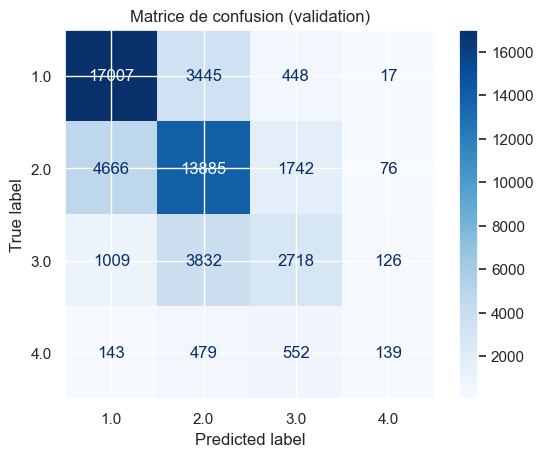

In [40]:
# Matrice de confusion
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion (validation)")
plt.show()

### Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=0
)

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_valid_scaled)

print("Rapport de classification - Logistic Regression :")
print(classification_report(y_valid, y_pred_log))

Rapport de classification - Logistic Regression :
              precision    recall  f1-score   support

         1.0       0.68      0.73      0.70     20917
         2.0       0.64      0.38      0.48     20369
         3.0       0.28      0.23      0.25      7685
         4.0       0.08      0.55      0.13      1313

    accuracy                           0.51     50284
   macro avg       0.42      0.47      0.39     50284
weighted avg       0.59      0.51      0.53     50284



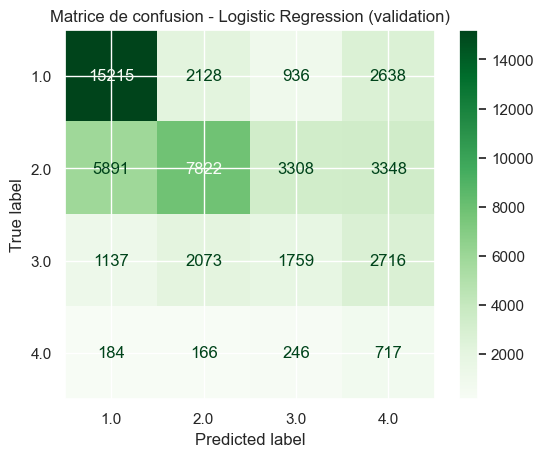

In [42]:
#  Matrice de confusion
cm_log = confusion_matrix(y_valid, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_model.classes_)
disp.plot(cmap='Greens')
plt.title("Matrice de confusion - Logistic Regression (validation)")
plt.show()

### AdaBoostClassifier

In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=0
)

# Entraînement du modèle
ada_model.fit(X_train, y_train)

# Prédictions
y_pred_ada = ada_model.predict(X_valid)

# Évaluation
print("Rapport de classification - AdaBoost :")
print(classification_report(y_valid, y_pred_ada))


Rapport de classification - AdaBoost :
              precision    recall  f1-score   support

         1.0       0.69      0.82      0.75     20917
         2.0       0.60      0.63      0.61     20369
         3.0       0.48      0.25      0.33      7685
         4.0       0.46      0.02      0.04      1313

    accuracy                           0.63     50284
   macro avg       0.56      0.43      0.43     50284
weighted avg       0.62      0.63      0.61     50284



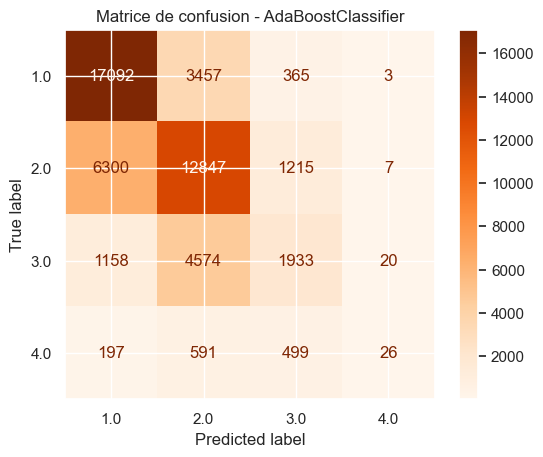

In [44]:
cm_ada = confusion_matrix(y_valid, y_pred_ada)
ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=ada_model.classes_).plot(cmap='Oranges')
plt.title("Matrice de confusion - AdaBoostClassifier")
plt.show()

### DecisionTreeClassifier

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
tree_model = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=None,           
    class_weight='balanced',  
    random_state=0
)

# Entraînement
tree_model.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Decision Tree :")
print(classification_report(y_valid, y_pred_tree))

Rapport de classification - Decision Tree :
              precision    recall  f1-score   support

         1.0       0.71      0.70      0.70     20917
         2.0       0.58      0.58      0.58     20369
         3.0       0.36      0.38      0.37      7685
         4.0       0.17      0.18      0.17      1313

    accuracy                           0.59     50284
   macro avg       0.45      0.46      0.46     50284
weighted avg       0.59      0.59      0.59     50284



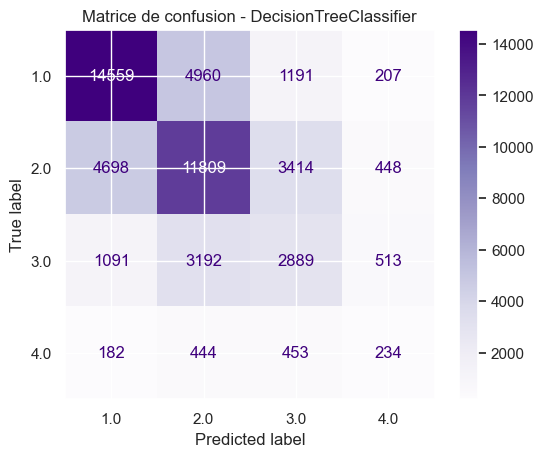

In [46]:
cm_tree = confusion_matrix(y_valid, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=tree_model.classes_).plot(cmap='Purples')
plt.title("Matrice de confusion - DecisionTreeClassifier")
plt.show()

### ExtraTreesClassifier

In [47]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Création du modèle
et_model = ExtraTreesClassifier(
    n_estimators=100,         
    max_depth=None,           
    class_weight='balanced',  
    random_state=0,
    n_jobs=-1                 
)

# Entraînement
et_model.fit(X_train, y_train)

# Prédictions
y_pred_et = et_model.predict(X_valid)

# Évaluation
print("Rapport de classification - Extra Trees :")
print(classification_report(y_valid, y_pred_et))

Rapport de classification - Extra Trees :
              precision    recall  f1-score   support

         1.0       0.74      0.81      0.77     20917
         2.0       0.64      0.67      0.65     20369
         3.0       0.48      0.36      0.41      7685
         4.0       0.34      0.12      0.18      1313

    accuracy                           0.66     50284
   macro avg       0.55      0.49      0.50     50284
weighted avg       0.65      0.66      0.65     50284



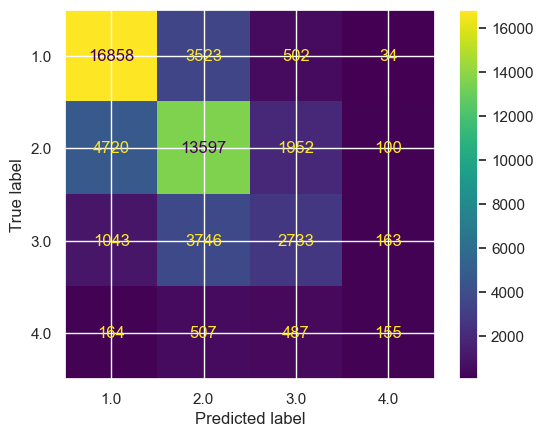

In [48]:
ConfusionMatrixDisplay.from_estimator(et_model, X_valid, y_valid)

### KNeighborsClassifier

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Normalisation (obligatoire pour KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Création du modèle KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5,    
    weights='distance'  
)

# Entraînement
knn_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_knn = knn_model.predict(X_valid_scaled)

# Évaluation
print("Rapport de classification - KNN :")
print(classification_report(y_valid, y_pred_knn))


Rapport de classification - KNN :
              precision    recall  f1-score   support

         1.0       0.72      0.76      0.74     20917
         2.0       0.61      0.62      0.61     20369
         3.0       0.42      0.36      0.39      7685
         4.0       0.24      0.11      0.16      1313

    accuracy                           0.63     50284
   macro avg       0.50      0.46      0.47     50284
weighted avg       0.61      0.63      0.62     50284



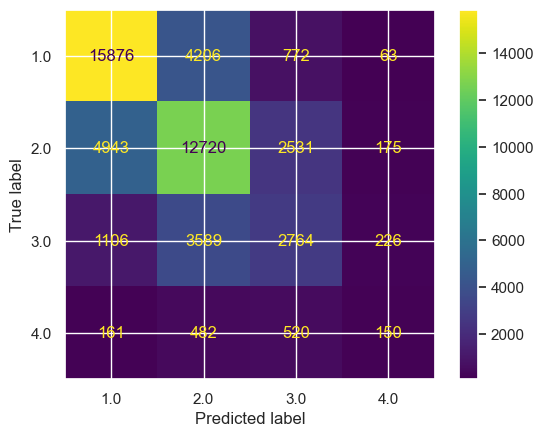

In [50]:
ConfusionMatrixDisplay.from_estimator(knn_model, X_valid_scaled, y_valid)

## HistGradientBoostingClassifier

In [51]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# Création et entraînement du modèle
hgb_model = HistGradientBoostingClassifier(random_state=0)
hgb_model.fit(X_train, y_train)

# Prédictions
y_pred_hgb = hgb_model.predict(X_valid)

# Évaluation
print("Rapport de classification - HistGradientBoosting :")
print(classification_report(y_valid, y_pred_hgb))

Rapport de classification - HistGradientBoosting :
              precision    recall  f1-score   support

         1.0       0.73      0.82      0.77     20917
         2.0       0.63      0.68      0.66     20369
         3.0       0.50      0.29      0.37      7685
         4.0       0.41      0.05      0.09      1313

    accuracy                           0.66     50284
   macro avg       0.57      0.46      0.47     50284
weighted avg       0.65      0.66      0.65     50284



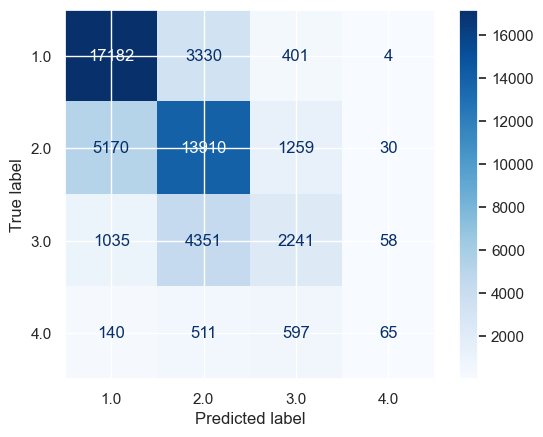

In [52]:
cm = confusion_matrix(y_valid, y_pred_hgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=hgb_model.classes_)
disp.plot(cmap="Blues")

## XGboost

In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Transformation temporaire de y (si nécessaire)
y_train_xgb = y_train - 1
y_valid_xgb = y_valid - 1

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0)

start_train = time.time()
xgb_model.fit(X_train, y_train_xgb)
train_time_xgb = time.time() - start_train

start_pred = time.time()
y_pred_xgb = xgb_model.predict(X_valid)
pred_time_xgb = time.time() - start_pred

# Remise en forme des prédictions pour affichage
y_pred_xgb += 1  # on revient à [1, 2, 3, 4]

print("Rapport de classification - XGBoost :")
print(classification_report(y_valid, y_pred_xgb))

Rapport de classification - XGBoost :
              precision    recall  f1-score   support

         1.0       0.73      0.82      0.78     20917
         2.0       0.63      0.68      0.65     20369
         3.0       0.50      0.30      0.38      7685
         4.0       0.47      0.07      0.12      1313

    accuracy                           0.67     50284
   macro avg       0.58      0.47      0.48     50284
weighted avg       0.65      0.67      0.65     50284



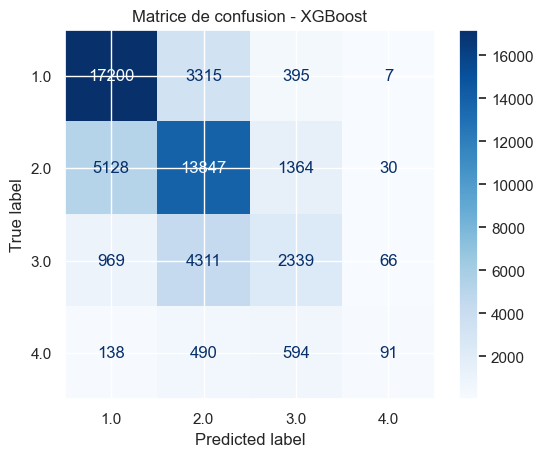

In [57]:
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_xgb, cmap='Blues')
plt.title("Matrice de confusion - XGBoost")
plt.show()

## lightgbm

In [58]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm_model = LGBMClassifier(class_weight='balanced', random_state=0)

start_train = time.time()
lgbm_model.fit(X_train, y_train)
train_time_lgbm = time.time() - start_train

start_pred = time.time()
y_pred_lgbm = lgbm_model.predict(X_valid)
pred_time_lgbm = time.time() - start_pred

print("Rapport de classification - LightGBM :")
print(classification_report(y_valid, y_pred_lgbm))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 253
[LightGBM] [Info] Number of data points in the train set: 452555, number of used features: 15
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Rapport de classification - LightGBM :
              precision    recall  f1-score   support

         1.0       0.75      0.79      0.77     20917
         2.0       0.69      0.46      0.55     20369
         3.0       0.36      0.38      0.37      7685
         4.0       0.13      0.63      0.21      1313

    accuracy                           0.59     50284
   macro avg       0.48      0.56      0.47     50284
weighted avg

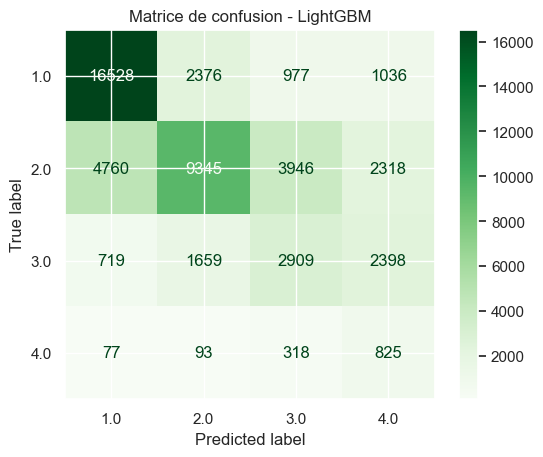

In [59]:
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_lgbm, cmap='Greens')
plt.title("Matrice de confusion - LightGBM")
plt.show()

### Code générique pour créer le tableau comparatif entre les modeles

In [61]:
import pandas as pd

# Résultats finaux des modèles
resultats_final = [
    {"Modèle": "HistGradientBoosting", "F1-score": 0.65, "Temps entraînement (s)": 4.13, "Temps prédiction (s)": 0.72},
    {"Modèle": "Bagging",              "F1-score": 0.64, "Temps entraînement (s)": 19.45, "Temps prédiction (s)": 0.98},
    {"Modèle": "RandomForest",         "F1-score": 0.66, "Temps entraînement (s)": 5.01, "Temps prédiction (s)": 0.56},
    {"Modèle": "ExtraTrees",           "F1-score": 0.65, "Temps entraînement (s)": 3.14, "Temps prédiction (s)": 0.62},
    {"Modèle": "AdaBoost",             "F1-score": 0.57, "Temps entraînement (s)": 2.86, "Temps prédiction (s)": 0.28},
    {"Modèle": "DecisionTree",         "F1-score": 0.59, "Temps entraînement (s)": 0.39, "Temps prédiction (s)": 0.01},
    {"Modèle": "KNN",                  "F1-score": 0.62, "Temps entraînement (s)": 0.50, "Temps prédiction (s)": 9.06},
    {"Modèle": "LogisticRegression",   "F1-score": 0.53, "Temps entraînement (s)": 1.50, "Temps prédiction (s)": 0.23},
    {"Modèle": "Dummy",                "F1-score": 0.24, "Temps entraînement (s)": 0.01, "Temps prédiction (s)": 0.00},
    {"Modèle": "LightGBM",             "F1-score": 0.61, "Temps entraînement (s)": train_time_lgbm, "Temps prédiction (s)": pred_time_lgbm},
    {"Modèle": "XGBoost",              "F1-score": 0.65, "Temps entraînement (s)": train_time_xgb,  "Temps prédiction (s)": pred_time_xgb}
]

# Création du DataFrame
df_resultats = pd.DataFrame(resultats_final).sort_values(by="F1-score", ascending=False).reset_index(drop=True)

# Affichage
print("📊 Tableau comparatif des modèles :")
display(df_resultats)


📊 Tableau comparatif des modèles :


,Modèle,F1-score,Temps entraînement (s),Temps prédiction (s)
0,RandomForest,0.66,5.010000,0.56000
1,HistGradientBoosting,0.65,4.130000,0.72000
2,ExtraTrees,0.65,3.140000,0.62000
3,XGBoost,0.65,5.876424,0.07779
4,Bagging,0.64,19.450000,0.98000
5,KNN,0.62,0.500000,9.06000
6,LightGBM,0.61,13.027444,0.54414
7,DecisionTree,0.59,0.390000,0.01000
8,AdaBoost,0.57,2.860000,0.28000
9,LogisticRegression,0.53,1.500000,0.23000


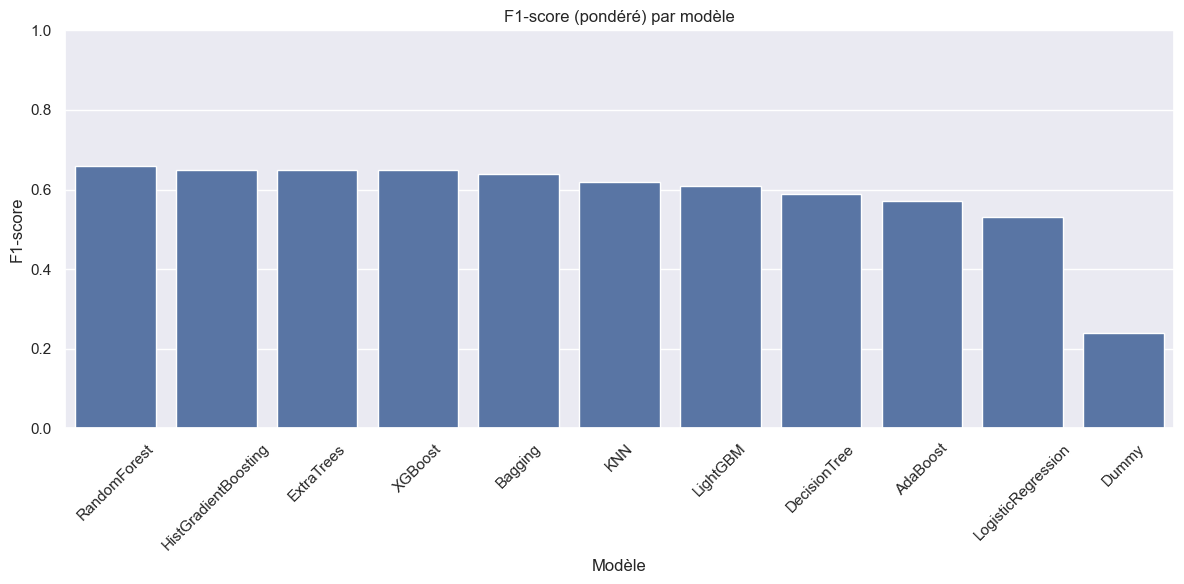

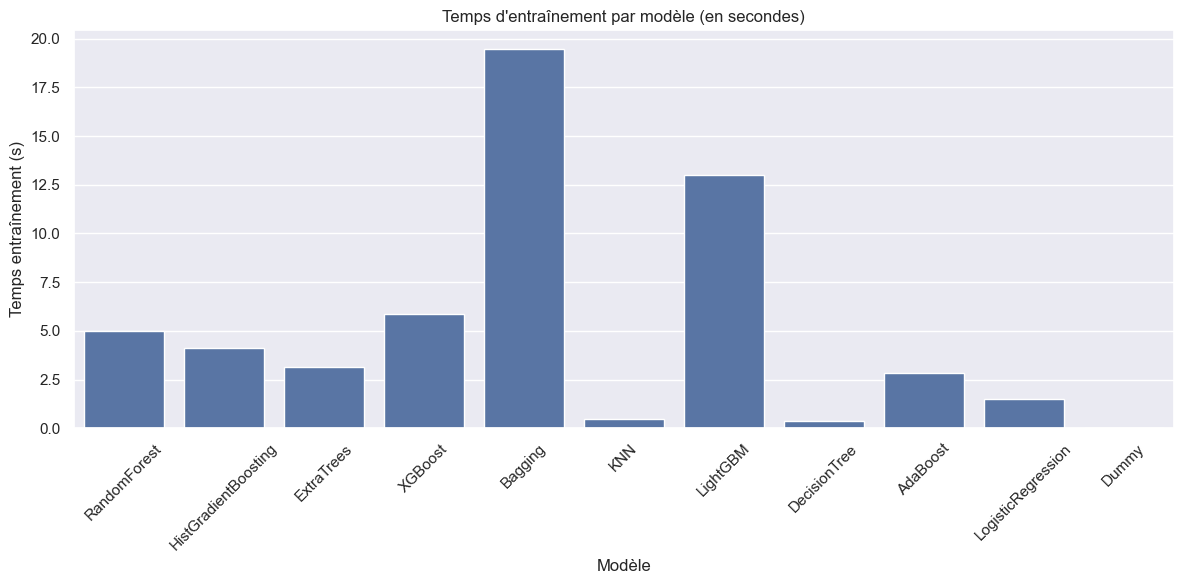

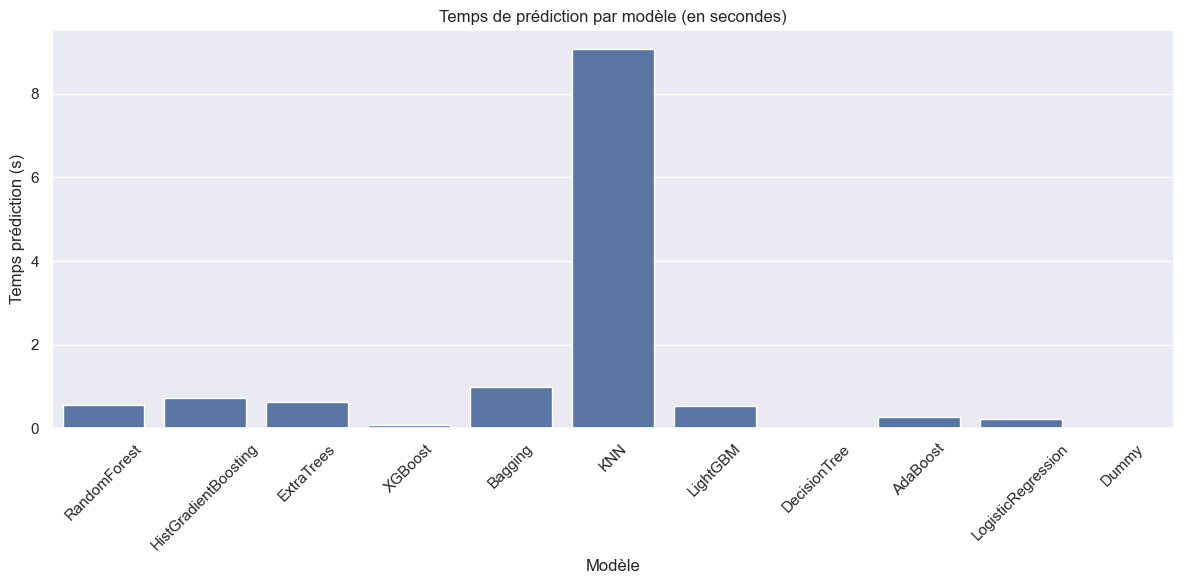

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pour un affichage plus clair
plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultats, x="Modèle", y="F1-score")
plt.title("F1-score (pondéré) par modèle")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultats, x="Modèle", y="Temps entraînement (s)")
plt.title("Temps d'entraînement par modèle (en secondes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_resultats, x="Modèle", y="Temps prédiction (s)")
plt.title("Temps de prédiction par modèle (en secondes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interprétation des résultats

La comparaison des modèles met en évidence plusieurs enseignements :

HistGradientBoosting, RandomForest et XGBoost obtiennent les meilleurs scores F1 (environ 0.65), ce qui les rend adaptés à notre tâche de classification multicatégorie déséquilibrée.

Le modèle BaggingClassifier offre un bon compromis entre performance (0.64) et robustesse, mais son temps d'entraînement est plus élevé.

LightGBM s'en sort légèrement moins bien que prévu (F1 ≈ 0.61), possiblement à cause de la sensibilité au prétraitement des données.

KNN montre un F1-score raisonnable (0.62), mais il est très coûteux en temps de prédiction (plus de 9s), ce qui peut être un frein en production.

LogisticRegression et DummyClassifier confirment leur rôle de baseline : leurs scores sont largement inférieurs (0.53 et 0.24).